# Final Figures

Adaptation from Kämper 
(https://github.com/merelkaemper/MSc-Thesis-main) and Lei et al. (https://github.com/amarallab/transportation_network_evolution).


## Imports

In [1]:
import itertools
import math
import glob
import random
import pickle
import os
import pandas as pd
import numpy as np
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import contextily as ctx
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore')

from datetime import date
from shapely.geometry import Point, LineString
from sklearn.preprocessing import quantile_transform
from matplotlib.patches import Patch
from scipy.stats import ks_2samp, combine_pvalues

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
# from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from joblib import Parallel, delayed

import sys
import random
import datetime
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

import duckdb

from datetime import date
from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [2]:
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import logging

# Tell the Matplotlib font manager to only print ERRORs, not WARNINGs
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [4]:
snellius = False
TRAINING_FROM_YEAR = 2019


import os
from pathlib import Path
if snellius:
	# Get the home directory path object
	home_dir = Path.home() 

	# Build a path to your code
	target_root = home_dir / "NS_Thesis"

	print(target_root)

elif snellius is False:
	# Change later to snellius $HOME or whatever folder you want to work in
	# target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")
	target_root = Path(r"C:\Users\Shaop\Documents\MSc-Thesis\MSc-Thesis\Bao")

	# Check if it exists before moving
	if target_root.exists():
		os.chdir(target_root)
		print(f"✅ Success! Moved to: {Path.cwd()}")
	else:
		print(f"❌ Error: The folder '{target_root}' does not exist.")

project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
# final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"


results_xgb = results_folder / "results_XGB"

results_xgb_hparam = results_folder / "results_XGB_HPARAM"

results_xgb_plots = media_folder / "results/results_XGB"

# results_classifiers = results_folder / "results_classifiers"
# results_classifiers = results_folder / "results_classifiers_DEF" # default hyperparameters, WITH class weights, no difference in results with or without class weights, so I will just use the default hyperparameters without class weights for the final results
results_classifiers_DEF_NCW = results_folder / "results_classifiers_DEF_NCW" # default hyperpameters, No Class Weights

station_coords_path = project_root / "downloads/data/raw/NS-stations/stations-2023-09-nl.csv"

import sys
sys.path.append(f"{project_root}/all_code/4_final_figures/")
from plot_style import *
stdrcparams(usetex=False)

# Load dataset with the features per trajectory per month

final_dataset_for_training_name = f"final_model_training_data_{TRAINING_FROM_YEAR}.parquet"
final_dataset_for_training_path = final_data_root / final_dataset_for_training_name

shape_file_path = project_root / "all_code/4_final_figures/data/gadm41_NLD_0.shp"
print(shape_file_path)

✅ Success! Moved to: C:\Users\Shaop\Documents\MSc-Thesis\MSc-Thesis\Bao
C:\Users\Shaop\Documents\MSc-Thesis\MSc-Thesis\Bao\all_code\4_final_figures\data\gadm41_NLD_0.shp


In [5]:
data = pd.read_parquet(final_dataset_for_training_path)

# Convert YearMonth to datetime format to extract year and month
data['YearMonth'] = pd.to_datetime(data['YearMonth'].astype(str))
data['YEAR'] = data['YearMonth'].dt.year
data['MONTH'] = data['YearMonth'].dt.month

# # Define the directory containing the result from all classifiers files
# results_dir = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/results_classifiers/'
results_dir = results_classifiers_DEF_NCW

In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 49788 entries, 0 to 49793
Data columns (total 73 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   source                            49788 non-null  str           
 1   target                            49788 non-null  str           
 2   YearMonth                         49788 non-null  datetime64[us]
 3   year                              49788 non-null  int64         
 4   month                             49788 non-null  int64         
 5   distance                          49788 non-null  int32         
 6   total_departure_delay_minutes     49788 non-null  float64       
 7   avg_departure_delay_minutes       49788 non-null  float64       
 8   count_delayed_departure_services  49788 non-null  int64         
 9   total_delay_minutes               49788 non-null  float64       
 10  avg_delay_minutes                 49788 non-null  float64     

In [7]:
data.head()

,source,target,YearMonth,year,month,distance,total_departure_delay_minutes,avg_departure_delay_minutes,count_delayed_departure_services,total_delay_minutes,...,ratio_intercity,ratio_intercity_direct,ratio_international,ratio_operational_exceptions,ratio_sprinter,season_ordinal,month_sin,month_cos,YEAR,MONTH
0,GD,GDG,2019-05-01,2019,5,3,658.0,0.29,238,7078.0,...,0.000,0.0,0.0,0.000,1.000,2,5.000000e-01,-0.866025,2019,5
1,GD,GDG,2019-12-01,2019,12,3,735.0,0.34,293,5663.0,...,0.000,0.0,0.0,0.000,1.000,1,-2.449294e-16,1.000000,2019,12
2,HMH,HMBV,2020-04-01,2020,4,2,325.0,0.34,172,3161.0,...,0.001,0.0,0.0,0.001,0.998,2,8.660254e-01,-0.500000,2020,4
3,HMH,HMBV,2020-12-01,2020,12,2,1050.0,1.11,479,1332.0,...,0.000,0.0,0.0,0.000,1.000,1,-2.449294e-16,1.000000,2020,12
4,HMH,HMBV,2021-12-01,2021,12,2,1251.0,1.28,492,2817.0,...,0.010,0.0,0.0,0.000,0.990,1,-2.449294e-16,1.000000,2021,12


In [8]:


feature_name_map = {
    # --- Topology Features ---
    'src_degree': 'Source Degree',
    'src_w_deg_inbound': 'Source Weighted Inbound Degree',
    'src_avg_distance_in': 'Source Avg Inbound Distance',
    'common_neighbors': 'Common Neighbors',
    'jaccard_coefficient': 'Jaccard Coefficient',
    'preferential_attachment': 'Preferential Attachment',
    'adamic_adar_index': 'Adamic-Adar Index',
    'resource_allocation_index': 'Resource Allocation Index',
    'src_avg_distance_out': 'Source Avg Outbound Distance',
    'src_w_deg_outbound': 'Source Weighted Outbound Degree',
    'src_w_deg_total': 'Source Weighted Total Degree',
    'src_avg_distance_total': 'Source Avg Total Distance',
    
    'tgt_degree': 'Target Degree',
    'tgt_w_deg_inbound': 'Target Weighted Inbound Degree',
    'tgt_w_deg_outbound': 'Target Weighted Outbound Degree',
    'tgt_w_deg_total': 'Target Weighted Total Degree',
    'tgt_avg_distance_in': 'Target Avg Inbound Distance',
    'tgt_avg_distance_out': 'Target Avg Outbound Distance',
    'tgt_avg_distance_total': 'Target Avg Total Distance',

    # --- Weather Features (Source) ---
    'src_avg_temperature_2m': 'Source Mean Temperature (2m)',
    'src_avg_rain': 'Source Sum Rain',
    'src_avg_snowfall': 'Source Sum Snowfall',
    'src_avg_snow_depth': 'Source Mean Snow Depth',
    'src_avg_wind_speed_10m': 'Source Mean Wind Speed (10m)',
    'src_avg_wind_gusts_10m': 'Source Max Wind Gusts (10m)',
    'src_avg_soil_temperature': 'Source Mean Soil Temperature',

    # --- Weather Features (Target) ---
    'tgt_avg_temperature_2m': 'Target Mean Temperature (2m)',
    'tgt_avg_rain': 'Target Sum Rain',
    'tgt_avg_snowfall': 'Target Sum Snowfall',
    'tgt_avg_snow_depth': 'Target Mean Snow Depth',
    'tgt_avg_wind_speed_10m': 'Target Mean Wind Speed (10m)',
    'tgt_avg_wind_gusts_10m': 'Target Max Wind Gusts (10m)',
    'tgt_avg_soil_temperature': 'Target Mean Soil Temperature',

    # --- Cyclical & Calendar Features ---
    'season_ordinal': 'Season (Ordinal)',
    'month_sin': 'Month (Sine)',
    'month_cos': 'Month (Cosine)',
    'month': 'Month',
    'total_holidays': 'Total Holidays',
    'holiday_density_ratio': 'Holiday Density Ratio',
    'weekend_days': 'Weekend Days',
    'working_days': 'Working Days',

    # --- Operational Features ---
    'distance': 'Distance',
	'last_active_volume': 'Scheduled Trajectories of Last Active Month',
    'months_since_last_service': 'Months Since Last Service',
    'decayed_edge_weight': 'Decayed Edge Weight',
    'is_new_or_stale_route': 'New or Stale Route',
    'ratio_intercity': 'Ratio Intercity',
    'ratio_intercity_direct': 'Ratio Intercity Direct',
    'ratio_international': 'Ratio International',
    'ratio_operational_exceptions': 'Ratio Operational Exceptions',
    'ratio_sprinter': 'Ratio Sprinter',

    # --- Target & Dropped Features (Included for completeness here) ---
    'target_binary': 'Target Binary',
    'train_type_counts': 'Train Type Counts',
    'last_active_month': 'Last Active Month'
}

## General Figures

### Graph on Map

Background map from
https://gadm.org/download_country.html

UNCOMMENT LATER WHEN PUSH MAIN

In [ ]:
# # Map for disruoted lines
# # Function to visualize the graph on a custom map of the Netherlands
# def visualize_graph_on_custom_map(graph, station_coords, shapefile_path,title="Graph on Map"):
# 	# Load the shapefile
# 	gdf_netherlands = gpd.read_file(shapefile_path)
	
# 	# Filter out unused stations
# 	used_stations = set(graph.nodes())
# 	filtered_coords = {station: coords for station, coords in station_coords.items() if station in used_stations}
	
# 	# Create a GeoDataFrame for stations
# 	gdf_nodes = gpd.GeoDataFrame(
# 		{'Station': list(filtered_coords.keys())},
# 		geometry=[Point(filtered_coords[station]['geo_lng'], filtered_coords[station]['geo_lat']) for station in filtered_coords],
# 		crs="EPSG:4326"
# 	)

# 	# Convert to the same CRS as the shapefile
# 	gdf_nodes = gdf_nodes.to_crs(gdf_netherlands.crs)
	
# 	# Create a GeoDataFrame for edges
# 	edge_list = []
# 	for u, v, data in graph.edges(data=True):
# 		if u in filtered_coords and v in filtered_coords:
# 			point_u = Point(filtered_coords[u]['geo_lng'], filtered_coords[u]['geo_lat'])
# 			point_v = Point(filtered_coords[v]['geo_lng'], filtered_coords[v]['geo_lat'])
# 			line = LineString([point_u, point_v])
# 			edge_list.append({'geometry': line, 'weight': data['ratio_arrival_delayed']})
	
# 	gdf_edges = gpd.GeoDataFrame(edge_list, crs="EPSG:4326")
# 	gdf_edges = gdf_edges.to_crs(gdf_netherlands.crs)

# 	fig, ax = plt.subplots(figsize=(12, 12))

# 	# Plot the shapefile (using NS colors from: https://www.ns.nl/platform/fundamentals/colours.html)
# 	gdf_netherlands.plot(ax=ax, color='#FFC917', edgecolor='#FFC917')
	
# 	# Calculate node sizes based on degree
# 	node_sizes = [graph.degree(node) * 10 for node in graph.nodes()]

# 	# Plot the stations
# 	gdf_nodes.plot(ax=ax, color='#003082', markersize=node_sizes, alpha=0.6)

# 	# Plot the edges with weight
# 	gdf_edges.plot(ax=ax, linewidth=gdf_edges['weight'], alpha=0.6, edgecolor='#003082')
		
# 	# Remove axis ticks and labels
# 	ax.set_xticks([])
# 	ax.set_yticks([])
# 	ax.set_xticklabels([])
# 	ax.set_yticklabels([])
	
# 	# Remove the border
# 	ax.spines['top'].set_visible(False)
# 	ax.spines['bottom'].set_visible(False)
# 	ax.spines['left'].set_visible(False)
# 	ax.spines['right'].set_visible(False)
# 	plt.show()

# # Load station coordinates, keep_default na False to prevent New Amsterdam bug
# station_coords = pd.read_csv(station_coords_path, keep_default_na=False)

# # Filter to only include stations in the Netherlands
# station_coords = station_coords[station_coords['country'] == 'NL']

# # Ensure coordinates are numeric
# station_coords['geo_lat'] = pd.to_numeric(station_coords['geo_lat'], errors='coerce')
# station_coords['geo_lng'] = pd.to_numeric(station_coords['geo_lng'], errors='coerce')

# # Convert station coordinates to a dictionary
# station_coords_dict = station_coords.set_index('code')[['geo_lat', 'geo_lng']].T.to_dict()

# # Filter the data for a specific month
# year = 2024
# month = 4
# graph_data = data[(data['YEAR'] == year) & (data['MONTH'] == month)]

# # Filter stations that are used in the edges
# used_stations = set(graph_data['source']).union(set(graph_data['target']))
# station_coords_dict = {station: station_coords_dict[station] for station in used_stations if station in station_coords_dict}

# # Create edges GeoDataFrame
# edges = []
# for _, row in graph_data.iterrows():
# 	source = row['source']
# 	target = row['target']
# 	rides_planned = row['ratio_arrival_delayed']
	
# 	if source in station_coords_dict and target in station_coords_dict:
# 		source_coords = Point(station_coords_dict[source]['geo_lng'], station_coords_dict[source]['geo_lat'])
# 		target_coords = Point(station_coords_dict[target]['geo_lng'], station_coords_dict[target]['geo_lat'])
# 		line = LineString([source_coords, target_coords])
# 		edges.append({'geometry': line, 'weight': rides_planned})

# gdf_edges = gpd.GeoDataFrame(edges, geometry='geometry', crs="EPSG:4326")

# # Create the graph
# graph = nx.from_pandas_edgelist(graph_data, 'source', 'target', edge_attr=True)

# # Visualize the graph on the custom map
# # visualize_graph_on_custom_map(graph, station_coords_dict, shapefile_path, title=f" Proportion Train Services Delayed ({year}-{month:02d})")
# visualize_graph_on_custom_map(graph, station_coords_dict, shape_file_path)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Shaop\\Documents\\MSc-Thesis\\MSc-Thesis\\Bao\\downloads\\data\\raw\\NS-stations\\stations-2023-09-nl.csv'

In [11]:
# import os
# import json
# from pathlib import Path
# import pandas as pd

# # 1. Define the path to your saved file
# rail_network_file = Path("downloads/data/raw/railway_map/rail_network.json")

# station_df_codes = used_stations
# stations_df = pd.read_csv(station_coords_path, keep_default_na=False)


# # 2. Open and read the file
# try:
#     with open(rail_network_file, "r") as f:
#         data = json.load(f)  # Parses the file directly into a dictionary
        
#     print("File loaded successfully!")
    
#     # 3. Verify it's working by printing the keys
#     print(f"Root keys: {list(data.keys())}")
    
# except FileNotFoundError:
#     print(f"Could not find file at: {rail_network_file}")
# except json.JSONDecodeError:
#     print("The file exists but contains invalid JSON.")
    

# import matplotlib.pyplot as plt
# import geopandas as gpd
# from shapely.geometry import LineString

# import pandas as pd

# def extract_connections_for_plotting(geojson_data):
#     payload = geojson_data.get("payload", {})
#     features = payload.get("features", [])

#     if not features:
#         print("No features found.")
#         return pd.DataFrame() # Return empty if nothing found

#     connections = []
#     for feature in features:
#         properties = feature.get("properties", {})
#         geometry = feature.get("geometry", {}).get("coordinates", [])
        
#         from_station = properties.get("from").upper()
#         to_station = properties.get("to").upper()

#         if (from_station in station_df_codes) and (to_station in station_df_codes): # only include valid stations from NS stations_df
#             connections.append({
#                 "From_Station": from_station,
#                 "To_Station": to_station,
#                 "Coordinates": geometry
#             })

#     return pd.DataFrame(connections)

# # Generate df for plotting
# connections_df = extract_connections_for_plotting(data)

# print(f"DataFrame ready! Contains {len(connections_df)} track segments.")
# print(connections_df.head())

# # 1. Convert the coordinate lists into Shapely LineString objects
# connections_df['geometry'] = connections_df['Coordinates'].apply(LineString)

# # 2. Create the GeoDataFrame for Connections (Tracks)
# connections_gdf = gpd.GeoDataFrame(
#     connections_df,
#     geometry='geometry',
#     crs="EPSG:4326"
# )

# used_codes_df = pd.DataFrame({'used_code': list(station_df_codes)})
# filtered_stations_df = duckdb.sql("""
#     SELECT s.* FROM stations_df s
#     JOIN used_codes_df u ON s.code = u.used_code
# """).df()

# # 3. Create the GeoDataFrame for Stations (Points)
# stations_gdf = gpd.GeoDataFrame(
#     filtered_stations_df,
#     geometry=gpd.points_from_xy(filtered_stations_df["geo_lng"], filtered_stations_df["geo_lat"]),
#     crs="EPSG:4326"
# )

# # Load the Netherlands shapefile
# nl_shape_gdf = gpd.read_file(shape_file_path)

# # Ensure the coordinate system matches your GPS coordinates (EPSG:4326)
# if nl_shape_gdf.crs != "EPSG:4326":
#     nl_shape_gdf = nl_shape_gdf.to_crs("EPSG:4326")

# # --- PLOTTING ---
# fig, ax = plt.subplots(figsize=(12, 12))

# # 1. Plot Background Map (Light Gray)
# nl_shape_gdf.plot(
#     ax=ax, 
#     color="#EAEAEA",       # Soft gray landmass
#     edgecolor="white",     # Clean white borders (if your shapefile has provinces)
#     linewidth=1,
#     zorder=0               # Forces the map to the very bottom
# )

# # 2. Plot Tracks (Blue lines)
# connections_gdf.plot(
#     ax=ax, 
#     color="blue", 
#     linewidth=0.8, 
#     alpha=0.6, 
#     label="Rail Tracks",
#     zorder=1               # Sits on top of the map
# )

# # 3. Plot Stations (Red dots)
# stations_gdf.plot(
#     ax=ax, 
#     color="red", 
#     markersize=15, 
#     alpha=1.0, 
#     label="Stations", 
#     zorder=2               # Sits on top of everything
# )

# # Styling
# ax.set_title("Railway Map of the Netherlands", fontsize=16)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# ax.grid(True, linestyle='--', alpha=0.5)

# # Create a custom legend 
# import matplotlib.lines as mlines
# track_handle = mlines.Line2D([], [], color='blue', linewidth=1, label='Tracks')
# station_handle = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=5, label='Stations')
# ax.legend(handles=[track_handle, station_handle])

# plt.show()


### Total services scheduled

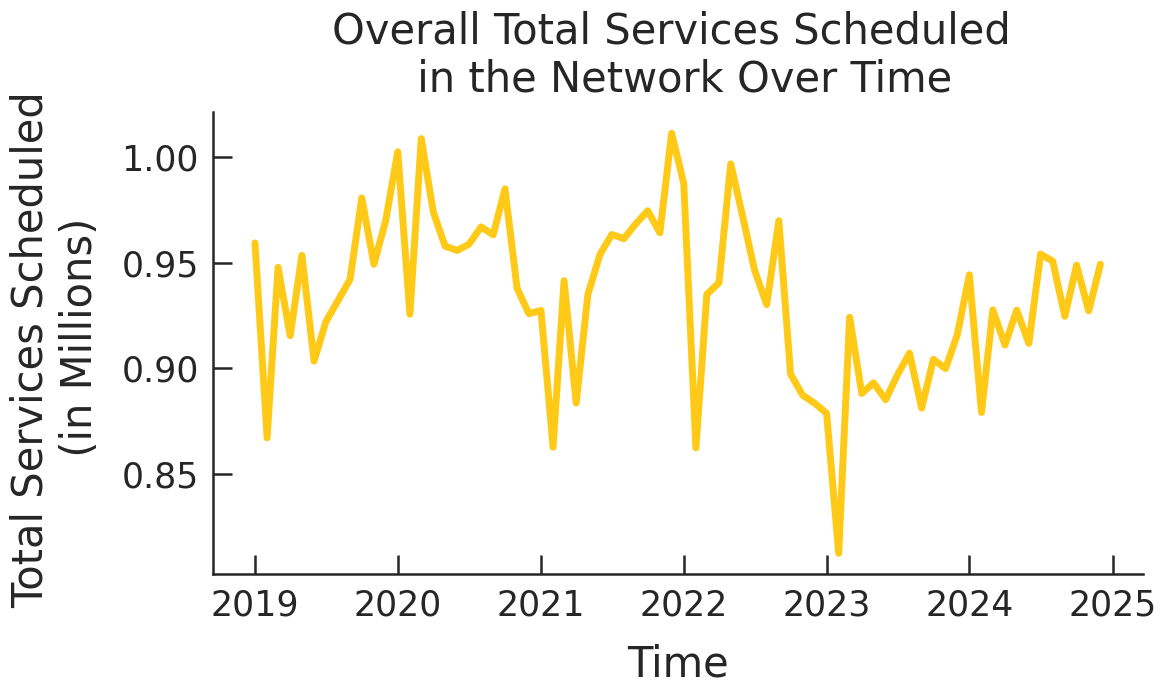

In [10]:
# PROPORTION DELAYED
# Group by 'YearMonth' and calculate the total services (with > 4) for each month
monthly_sum_services = data.groupby('YearMonth')['total_services'].sum().reset_index()

# Ensure data is sorted by 'YearMonth'
monthly_sum_services = monthly_sum_services.sort_values(by='YearMonth')

# Create the plot, using NS yellow for the line from: https://www.ns.nl/platform/fundamentals/colours.html 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_sum_services['YearMonth'], 
        monthly_sum_services['total_services'] / 1_000_000, 
        label='Total Services Scheduled', 
        color="#FFC917")

# Format the x-axis to show only the years
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# # Remove the top and right ticks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Total Services Scheduled \n (in Millions)')
ax.set_title('Overall Total Services Scheduled \n in the Network Over Time')

plt.show()

### Proportion Delayed 
(e.g. the varying monthly class imbalance for the significantly delayed target class)

Indicates median shifted up over time

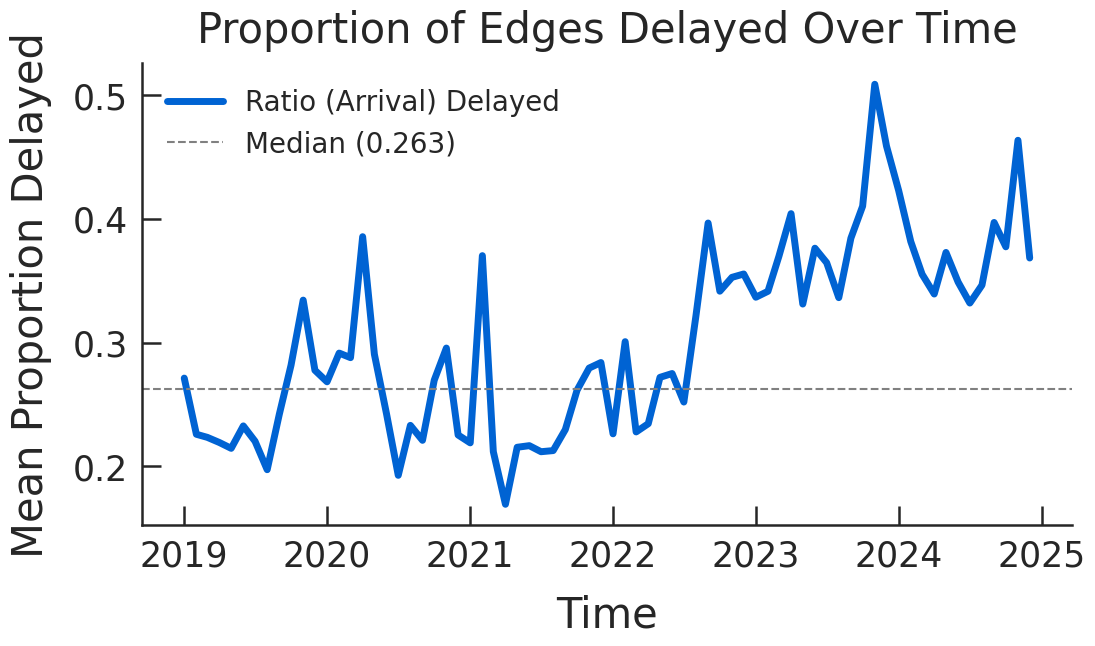

In [11]:
# PROPORTION DELAYED
# Group by 'YearMonth' and calculate the mean 'Proportion delayed' for each month
monthly_mean_delayed = data.groupby('YearMonth')['ratio_arrival_delayed'].mean().reset_index()

# Ensure data is sorted by 'YearMonth'
monthly_mean_delayed = monthly_mean_delayed.sort_values(by='YearMonth')

# Create the plot, using NS blue for the line
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_mean_delayed['YearMonth'], monthly_mean_delayed['ratio_arrival_delayed'], 
        label='Ratio (Arrival) Delayed', color='#0063D3')

# --- Calculate and plot the median line ---
median_delayed = data['ratio_arrival_delayed'].median()
ax.axhline(y=median_delayed, color='gray', linestyle='--', linewidth=1.5, label=f'Median ({median_delayed:.3f})')
# -----------------------------------------------

# Format the x-axis to show only the years
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove the top and right ticks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Mean Proportion Delayed')
ax.set_title('Proportion of Edges Delayed Over Time')

# Display the legend to show the median label
ax.legend(frameon=False) 

plt.show()

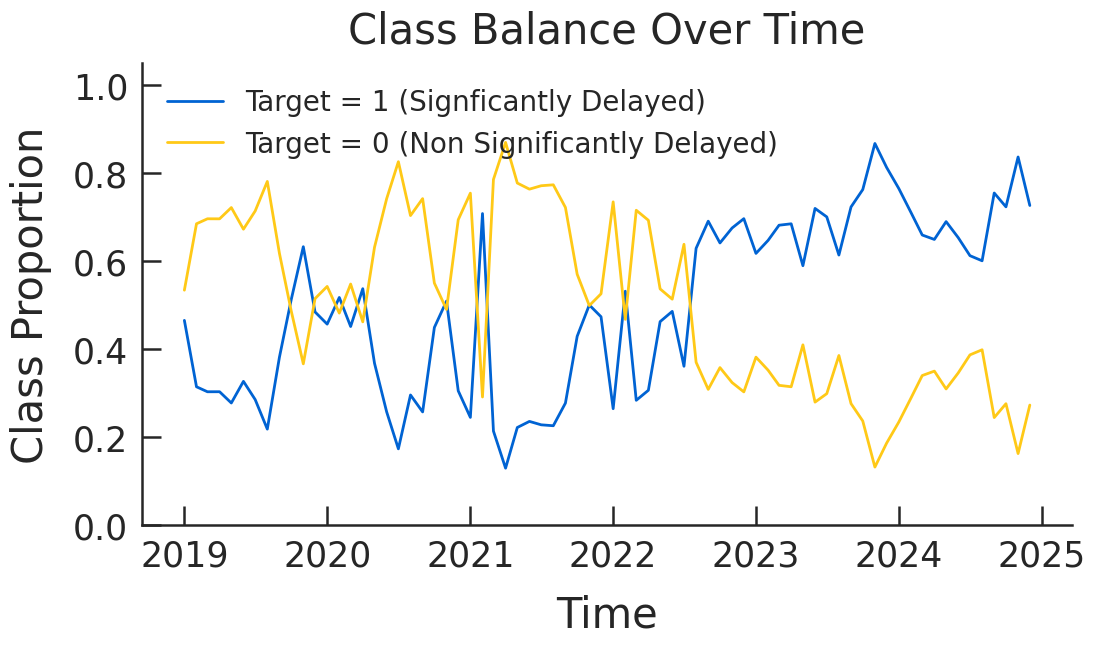

In [12]:
import duckdb
import matplotlib.pyplot as plt

# Aggregate the class fractions efficiently
monthly_data = duckdb.sql("""
    SELECT 
        YearMonth,
        AVG(target_binary) AS fraction_1,
        1.0 - AVG(target_binary) AS fraction_0
    FROM data
    GROUP BY YearMonth
    ORDER BY YearMonth
""").df()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Target = 1 (Significantly Delayed) in NS Blue
ax.plot(monthly_data['YearMonth'], monthly_data['fraction_1'], 
        label='Target = 1 (Signficantly Delayed)', color='#0063D3', linewidth=2)

# Plot Target = 0 (Not Delayed) in NS Yellow
ax.plot(monthly_data['YearMonth'], monthly_data['fraction_0'], 
        label='Target = 0 (Non Significantly Delayed)', color='#FFC917', linewidth=2)

# Format the x-axis to show only the years
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove the top and right ticks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Set y-axis limits to frame the full 0.0 to 1.0 proportion scale
ax.set_ylim(0, 1.05)

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Class Proportion')
ax.set_title('Class Balance Over Time')

# Cleanly display the legend
ax.legend(frameon=False, loc='best')

# plt.tight_layout()
plt.show()

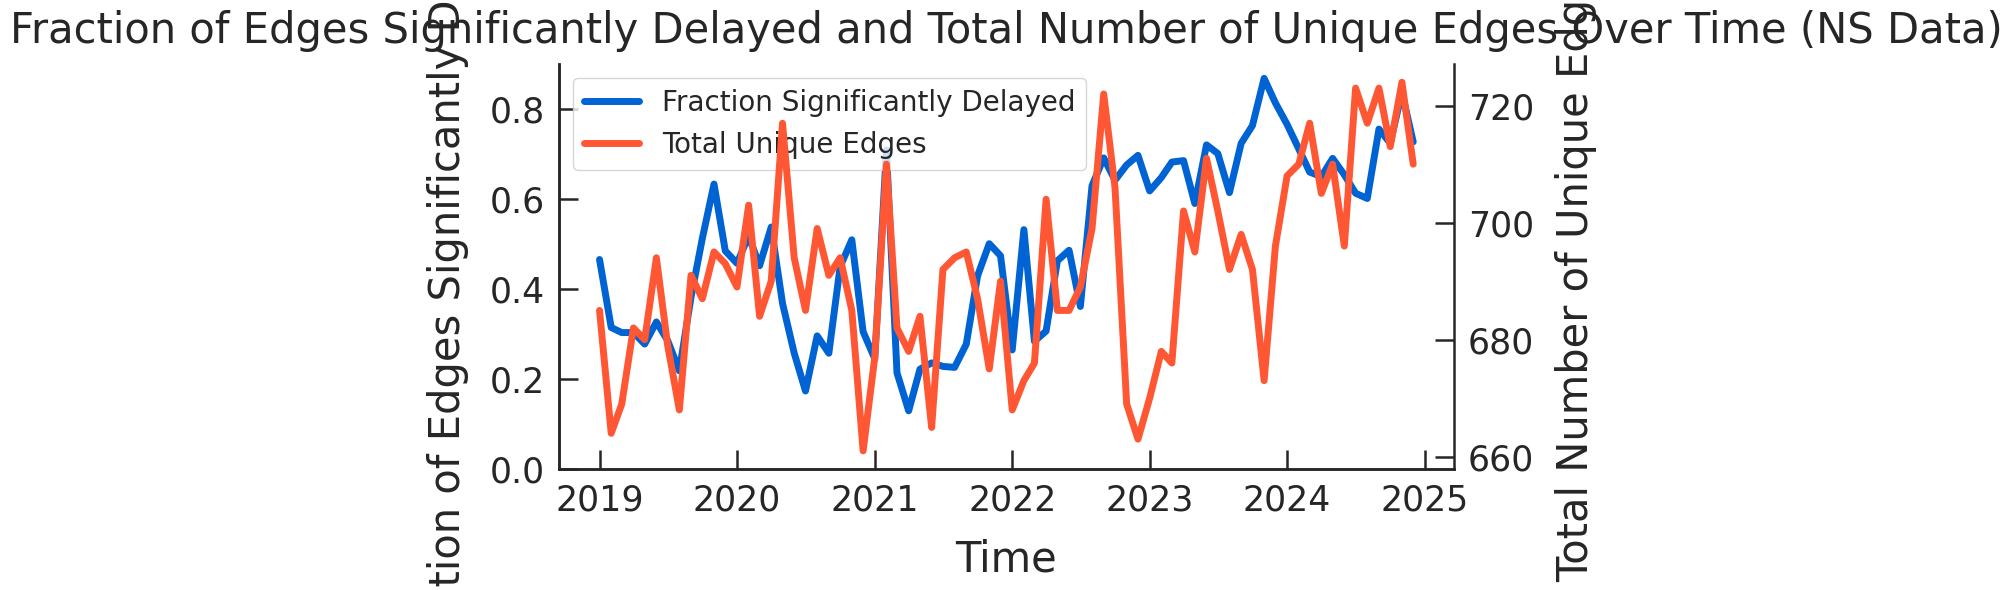

In [13]:
# Create a plot for fraction removed
monthly_mean_sig_delayed = data.groupby('YearMonth')['target_binary'].mean().reset_index()

# Calculate the total number of edges per month
monthly_total_edges = data.groupby('YearMonth').size().reset_index(name='Total Edges')

# Merge the two dataframes on 'YearMonth' to ensure they align correctly
monthly_data = pd.merge(monthly_mean_sig_delayed, monthly_total_edges, on='YearMonth')

# Plotting the results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the fraction of edges significantly delayed
ax.plot(monthly_data['YearMonth'], monthly_data['target_binary'], label='Fraction Significantly Delayed', color='#0063D3')

# Plot the total number of edges on a secondary y-axis
ax2 = ax.twinx()
ax2.plot(monthly_data['YearMonth'], monthly_data['Total Edges'], label='Total Unique Edges', color='#FF5733')

# Format the x-axis to show only the years
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Remove the top and right ticks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax2.yaxis.set_ticks_position('right')

# Set y-axis limits for the fraction significantly delayed
ax.set_ylim(0, 0.9)

# Add labels and title
ax.set_xlabel('Time')
ax.set_ylabel('Fraction of Edges Significantly Delayed')
ax2.set_ylabel('Total Number of Unique Edges')
ax.set_title('Fraction of Edges Significantly Delayed and Total Number of Unique Edges Over Time (NS Data)')

# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
monthly_mean_sig_delayed.describe()

,YearMonth,target_binary
count,72,72.000000
mean,2021-12-15 22:40:00,0.497614
min,2019-01-01 00:00:00,0.129794
25%,2020-06-23 12:00:00,0.303499
50%,2021-12-16 12:00:00,0.505115
75%,2023-06-08 12:00:00,0.677215
max,2024-12-01 00:00:00,0.867756
std,NaN,0.196838


In [15]:
# MEAN CALCULATION
overall_mean_proportion_delayed = data['ratio_arrival_delayed'].mean()
overall_median_proportion_delayed = data['ratio_arrival_delayed'].median()

print(f"Overall mean proportion of delayed edges: {overall_mean_proportion_delayed:.4f}")
print(f"Overall mean proportion of delayed edges (binary target): {overall_median_proportion_delayed:.4f}")

Overall mean proportion of delayed edges: 0.3024
Overall mean proportion of delayed edges (binary target): 0.2630


In [16]:
melted_data = data.melt(
    id_vars=['YearMonth'], 
    value_vars=['source', 'target'], 
    value_name='node'
)

unique_nodes_per_month = melted_data.groupby('YearMonth')['node'].nunique()

print(f"""Total Number of Snapshots: {monthly_total_edges['YearMonth'].count()}""")
print(f"""Average number of Edges: {round(monthly_total_edges['Total Edges'].mean())}""")
print(f"""Average number of Nodes: {round(unique_nodes_per_month.mean())}""")

Total Number of Snapshots: 72
Average number of Edges: 692
Average number of Nodes: 247


### Feature Evaluation

In [17]:
# Weight features
topology_weight_feature = [
	'decayed_edge_weight', 
	'src_w_deg_inbound', 'src_w_deg_outbound', 'src_w_deg_total',
	'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
]

#consistent with prior
topology_features = [
    'src_degree', # number of connections
    'tgt_degree', # number of connections
	'src_avg_distance_in', 
	'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
	'adamic_adar_index', 'resource_allocation_index',
	'src_avg_distance_out', 'src_avg_distance_total',
	'tgt_avg_distance_in', 'tgt_avg_distance_out',
	'tgt_avg_distance_total',
]

weather_features = [
	'src_avg_temperature_2m', 'src_avg_rain', 'src_avg_snowfall',
	'src_avg_snow_depth', 'src_avg_wind_speed_10m',
	'src_avg_wind_gusts_10m', 'src_avg_soil_temperature',
	'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
	'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
	'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
]

# cyclical_features = [
# 	'season_ordinal', 'month_sin', 'month_cos'
# ]

# calendar_features = cyclical_features + ['total_holidays',
# 'holiday_density_ratio', 'weekend_days', 'working_days',
# 'month',
# ]

# operational feature engineering, define in paper
operational_features = [
	'distance',
	'last_active_volume', 
	'months_since_last_service', 
	'decayed_edge_weight',
	'is_new_or_stale_route',
	'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
	'ratio_operational_exceptions', 'ratio_sprinter',
]

# From historical service, not engineered
service_features = [
	'source', 'target', 'distance', 'year', 'month'
]

non_numeric_features = [
	'source', 'target', 'YearMonth', 'last_active_month',
]

all_num_features = topology_features + topology_weight_feature + weather_features + operational_features

# all_num_features = topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# all_features = service_features + topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_binary']

# features unknown at prediction time and utilized to calculate operational lag features and redundant 
features_to_drop = [
	'total_departure_delay_minutes', 'avg_departure_delay_minutes',
	'count_delayed_departure_services', 'total_delay_minutes',
	'avg_delay_minutes', 'count_delayed_services', 'total_services',
	'ratio_departure_delayed', 'ratio_arrival_delayed',
	'count_platform_changes', 'train_type_counts',
	'global_median', 'target_binary', 'raw_intercity',
	'raw_intercity_direct', 'raw_international', 'raw_exceptions',
	# topology redundant
	# 'src_avg_distance_out',
	# 'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
	# 'tgt_avg_distance_in', 'tgt_avg_distance_out',
	# 'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
	# 'tgt_degree',
	# 'tgt_avg_distance_total', 
	# weather redundant
	# 'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
	# 'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
	# 'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
	# cal redundant
	# 'month',
	# operational redundant
	# 'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
	# 'ratio_operational_exceptions', 'ratio_sprinter',
]

initial_cols_to_drop = ['train_type_counts', 'last_active_month']

In [18]:
feature_sets = {
	'TOP': topology_features,
	'WGT': topology_weight_feature,
	'WTH': weather_features,
	'OPS': operational_features,
	# 'CAL': calendar_features,
	
	# Combined feature sets 
	
	'TW':  topology_features + topology_weight_feature,
	# 'TWC':  topology_features + topology_weight_feature + calendar_features,
	'TWW': topology_features + topology_weight_feature + weather_features,
	'TWO': topology_features + topology_weight_feature + operational_features,
	'ALLF': topology_features + topology_weight_feature  + operational_features + weather_features
}
# Combine all feature sets into a single list
all_features = [feature for feature_list in feature_sets.values() for feature in feature_list]


## Simultaneous Testing

In [19]:
xgb_results_folder_path = results_xgb

# Loop through the directory, check if it's a file (not a sub-folder), and get the name

file_names = [f.name for f in xgb_results_folder_path.iterdir() if f.is_file()]
print(file_names)

# The asterisk (*) is a (regex) wildcard. This grabs ONLY .csv files.
csv_files = [f.name for f in xgb_results_folder_path.glob("*.csv")]

print(csv_files)


['balanced_acc_non.pkl', 'NS_C_ALLF_nonsimultaneous.pkl', 'NS_C_ALLF_SHAP.pkl', 'NS_C_ALLF_simultaneous.csv', 'NS_C_TWCO_nonsimultaneous.pkl', 'NS_C_TWCO_SHAP.pkl', 'NS_C_TWCO_simultaneous.csv', 'NS_C_TWCW_nonsimultaneous.pkl', 'NS_C_TWCW_SHAP.pkl', 'NS_C_TWCW_simultaneous.csv', 'NS_C_TW_nonsimultaneous.pkl', 'NS_C_TW_SHAP.pkl', 'NS_C_TW_simultaneous.csv', 'NS_I_OPS_nonsimultaneous.pkl', 'NS_I_OPS_SHAP.pkl', 'NS_I_OPS_simultaneous.csv', 'NS_I_TOP_nonsimultaneous.pkl', 'NS_I_TOP_SHAP.pkl', 'NS_I_TOP_simultaneous.csv', 'NS_I_WGT_nonsimultaneous.pkl', 'NS_I_WGT_SHAP.pkl', 'NS_I_WGT_simultaneous.csv', 'NS_I_WTH_nonsimultaneous.pkl', 'NS_I_WTH_SHAP.pkl', 'NS_I_WTH_simultaneous.csv']
['NS_C_ALLF_simultaneous.csv', 'NS_C_TWCO_simultaneous.csv', 'NS_C_TWCW_simultaneous.csv', 'NS_C_TW_simultaneous.csv', 'NS_I_OPS_simultaneous.csv', 'NS_I_TOP_simultaneous.csv', 'NS_I_WGT_simultaneous.csv', 'NS_I_WTH_simultaneous.csv']


In [20]:
import duckdb

# ## Individual sets
df_simultaneousClassification_TOP = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_I_TOP_simultaneous.csv'").df()

df_simultaneousClassification_WGT = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_I_WGT_simultaneous.csv'").df()

df_simultaneousClassification_WTH = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_I_WTH_simultaneous.csv'").df()

df_simultaneousClassification_OPS = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_I_OPS_simultaneous.csv'").df()

# df_simultaneousClassification_CAL = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_I_CAL_simultaneous.csv'").df()

# ## Intermediate 
df_simultaneousClassification_TW = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_C_TW_simultaneous.csv'").df()

# ## Combined sets
# df_simultaneousClassification_TWC = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_C_TWC_simultaneous.csv'").df()

df_simultaneousClassification_TWCW = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_C_TWCW_simultaneous.csv'").df()

df_simultaneousClassification_TWCO = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_C_TWCO_simultaneous.csv'").df()

df_simultaneousClassification_ALLF = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb}/NS_C_ALLF_simultaneous.csv'").df()

In [21]:

df_simultaneousClassification = {
	"Topological Features": df_simultaneousClassification_TOP,
	"Weight Features": df_simultaneousClassification_WGT,
	"Weather Features": df_simultaneousClassification_WTH,
	"Operational Features": df_simultaneousClassification_OPS,
	# "Calendar Features": df_simultaneousClassification_CAL,
	"Topological + Weight": df_simultaneousClassification_TW,
	# "Topological + Weight + Calendar": df_simultaneousClassification_TWC,
	"Topological + Weight + Weather": df_simultaneousClassification_TWCW,
	"Topological + Weight + Operational": df_simultaneousClassification_TWCO,
	"All Features": df_simultaneousClassification_ALLF
}

total_memory_mb = 0

print("Memory Usage per DataFrame:")
print("-" * 30)

for name, df in df_simultaneousClassification.items():
	# Calculate memory in bytes, then convert to Megabytes
	mem_bytes = df.memory_usage(deep=True).sum()
	mem_mb = mem_bytes / (1024 ** 2)
	total_memory_mb += mem_mb
	
	print(f"{name:<5} : {mem_mb:>6.2f} MB")

print("-" * 30)
print(f"TOTAL : {total_memory_mb:>6.2f} MB")

Memory Usage per DataFrame:
------------------------------
Topological Features :   0.42 MB
Weight Features :   0.42 MB
Weather Features :   0.42 MB
Operational Features :   0.42 MB
Topological + Weight :   0.42 MB
Topological + Weight + Weather :   0.42 MB
Topological + Weight + Operational :   0.42 MB
All Features :   0.42 MB
------------------------------
TOTAL :   3.40 MB


In [22]:
def pure_plot_confusion_matrix(cm, ax = None):
    classes = ['Not Sig. Delayed','Sig. Delayed']
    sns.heatmap(cm, square = True, annot= True, cbar = False, cmap=plt.cm.Blues,ax = ax,annot_kws={"fontsize":25})
    ax.set_ylim(0,2)
    ax.tick_params( bottom=False, right=False,left=False, labeltop=False, labelbottom=True)
    ax.invert_yaxis()
    ax.set(xticks = np.arange(cm.shape[1])+0.5,
           yticks = np.arange(cm.shape[0])+0.25,
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           ylabel = 'True label',
           xlabel = 'Predicted label') 

### CM XGB Sim

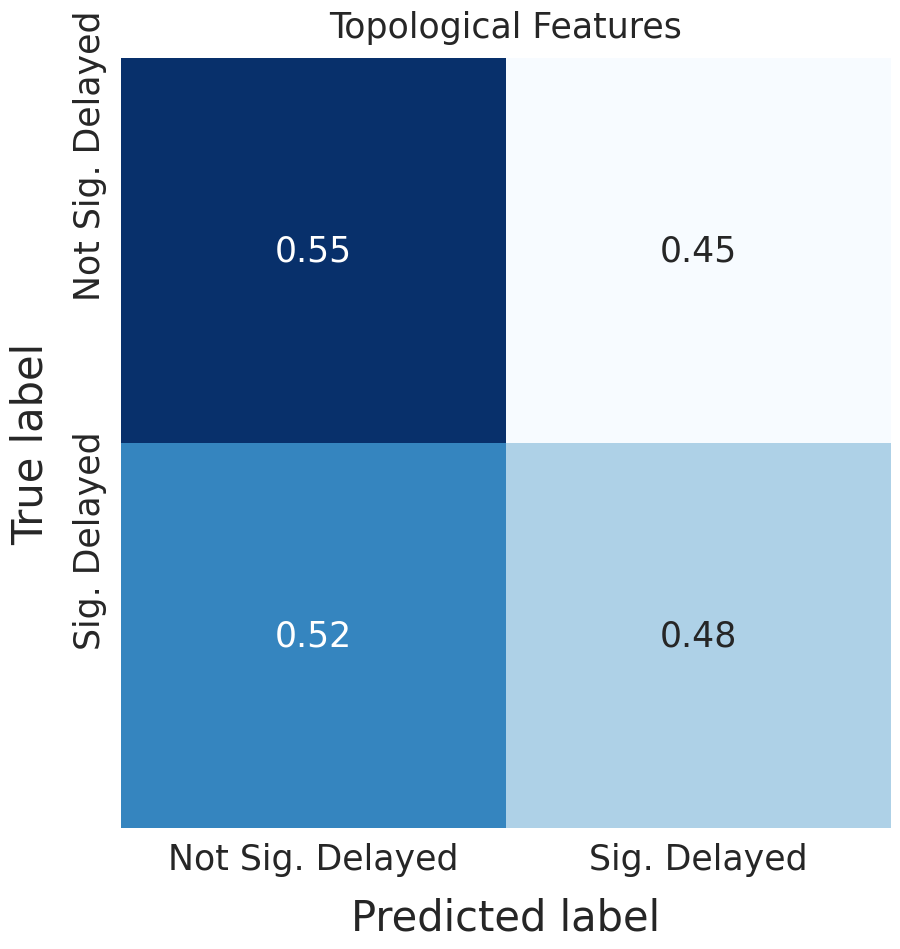

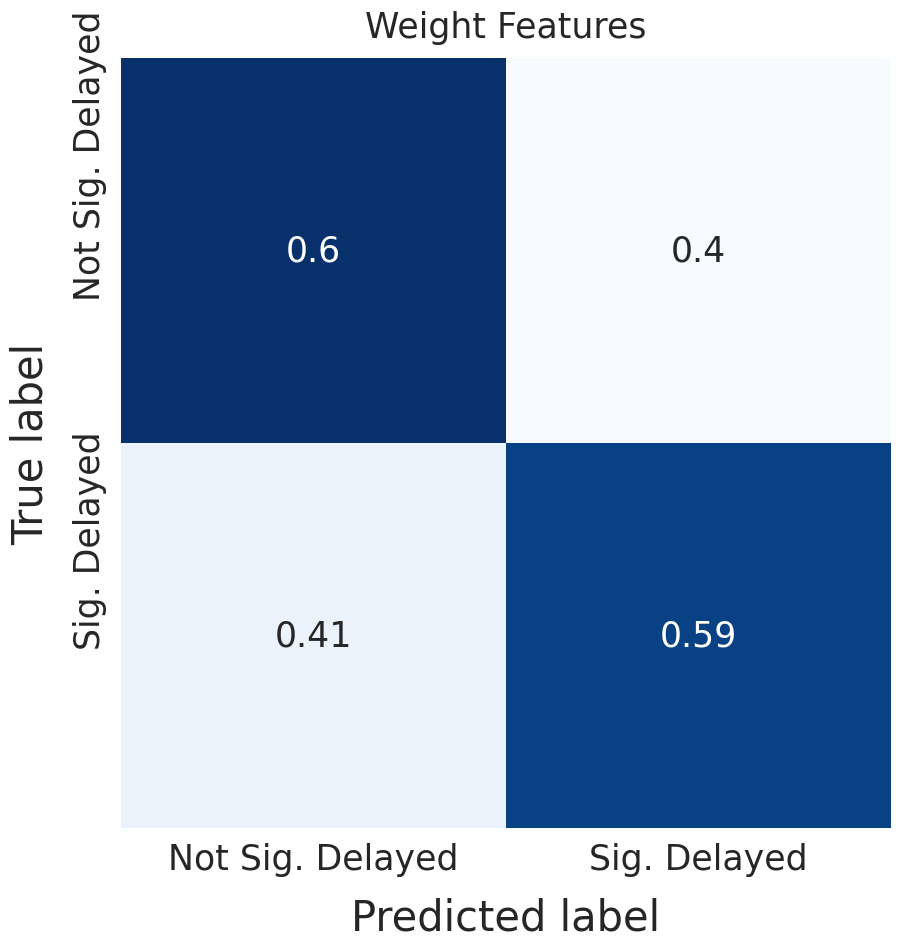

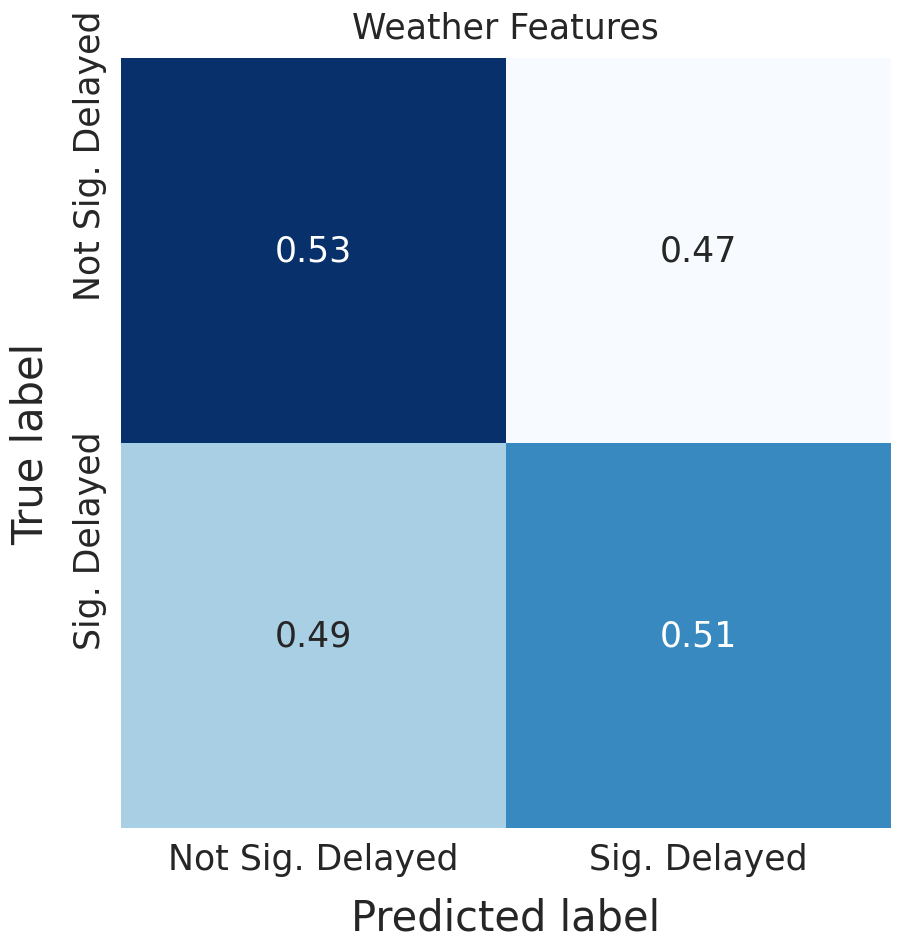

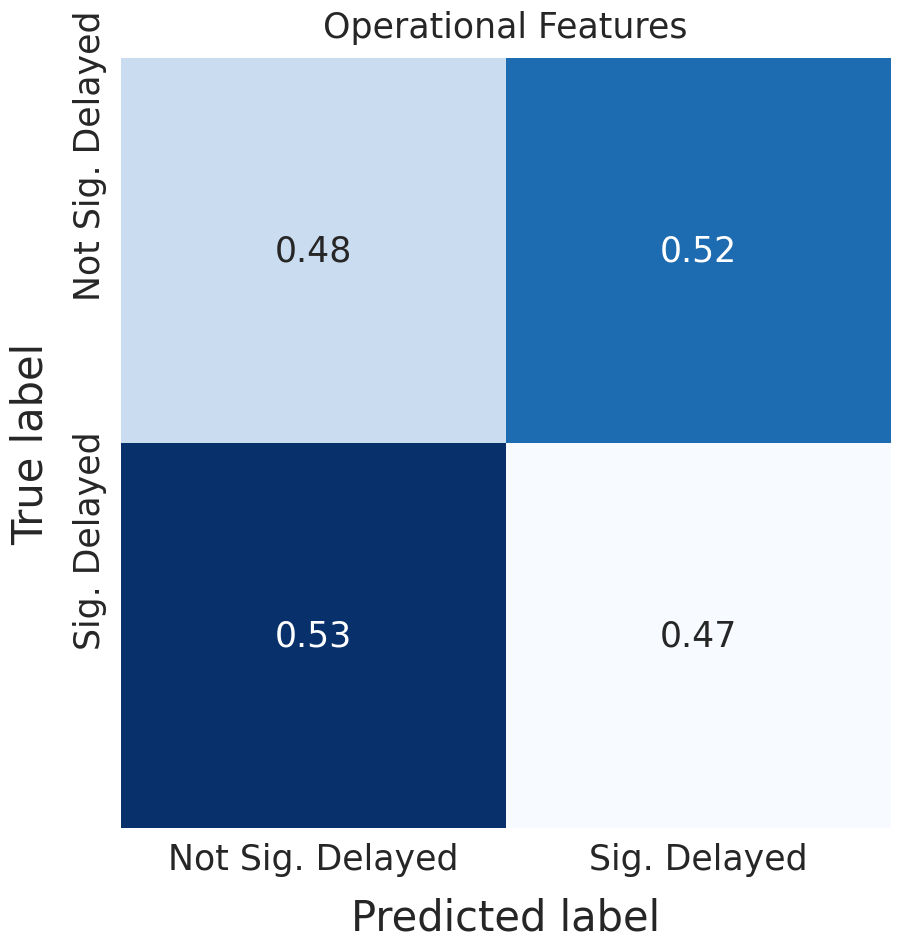

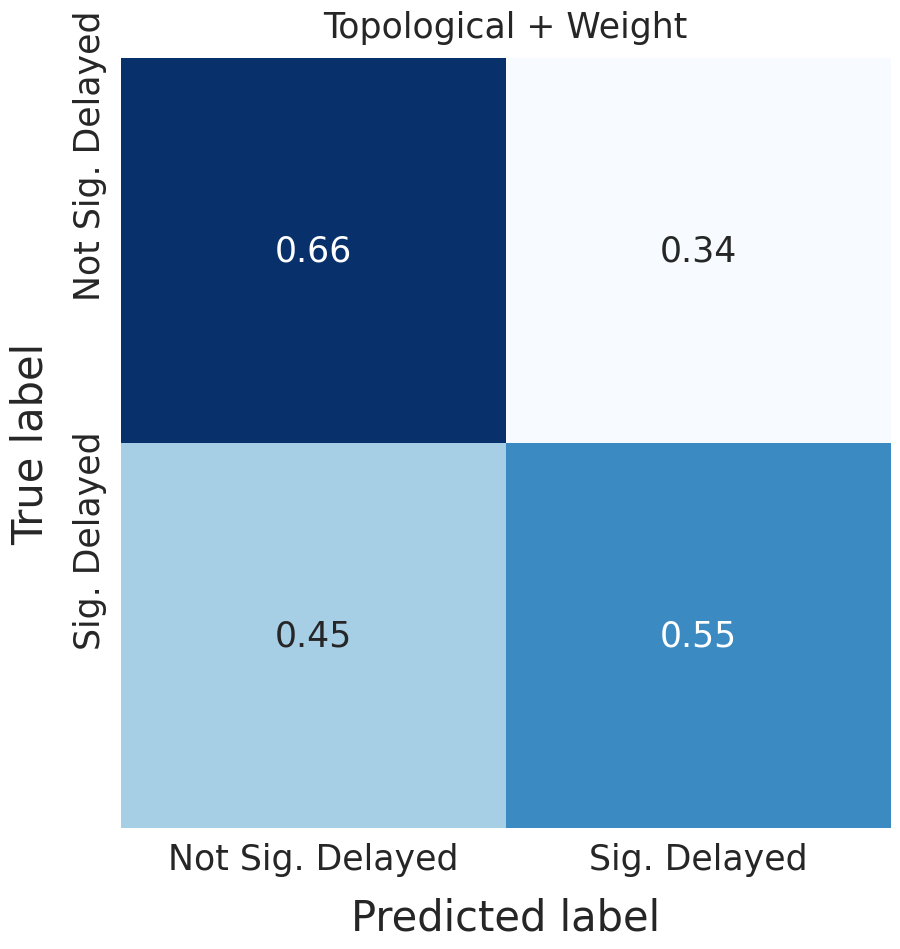

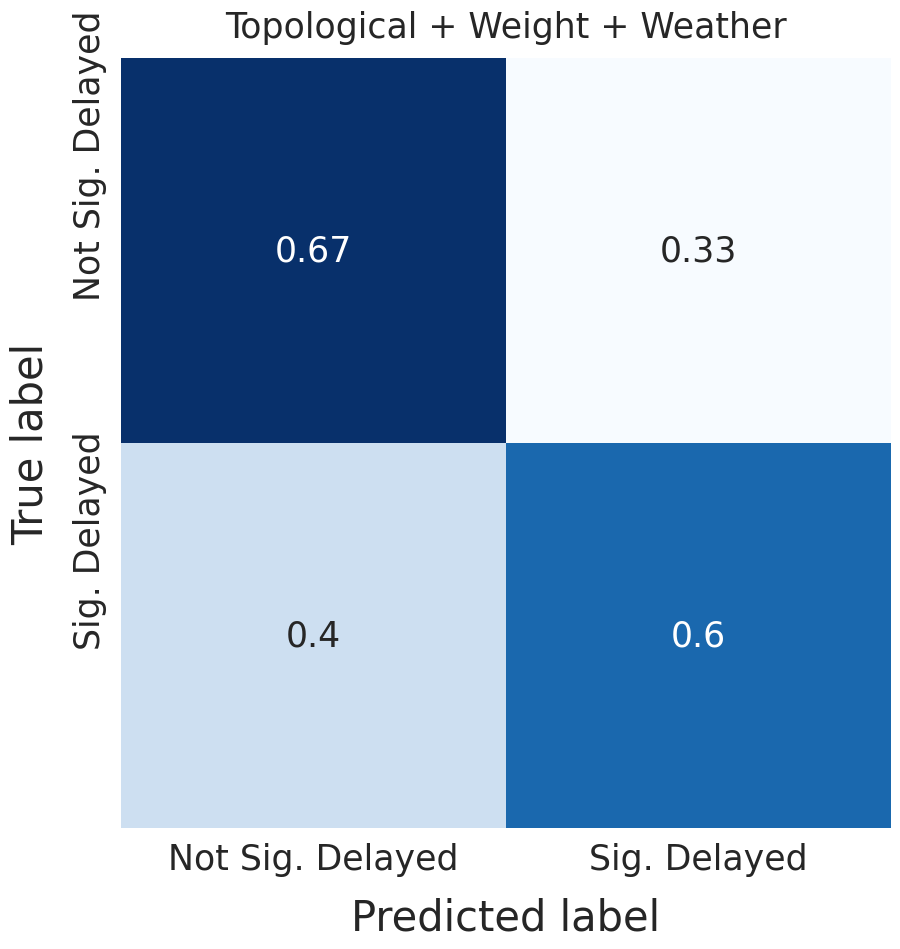

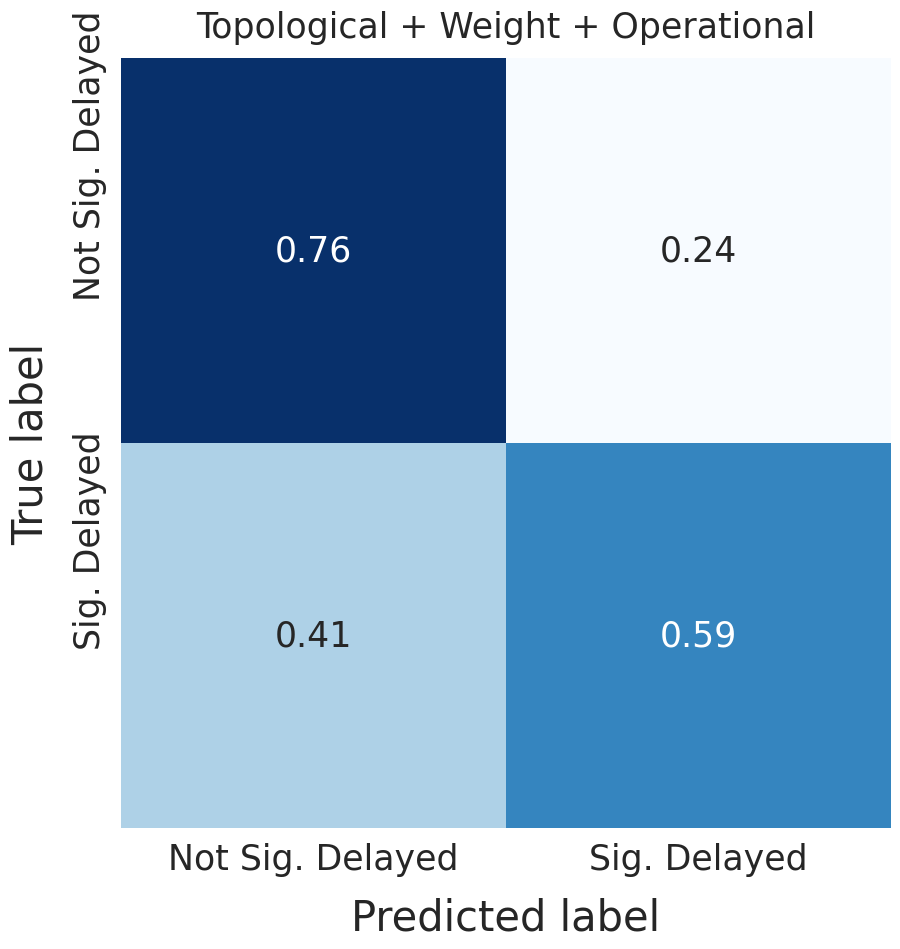

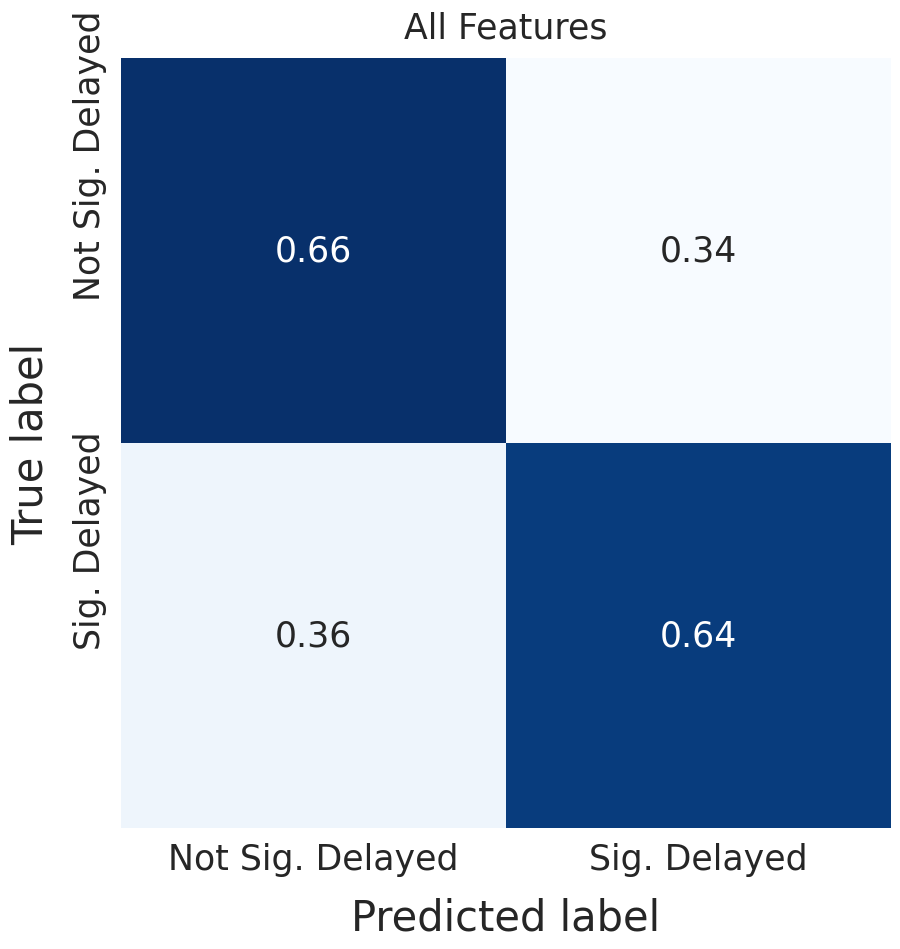

In [23]:
# Abbreviation Mapping Logic
name_to_suffix = {
    "Topological Features": "Top",
    "Weight Features": "Wgt",
    "Weather Features": "Wth",
    "Operational Features": "Ops",
    "Topological + Weight": "Tw",
    "Topological + Weight + Weather": "Twcw",
    "Topological + Weight + Operational": "Twco",
    "All Features": "Allf"
}

year = '2024-01'

# Visualization Export Execution
for name, df in df_simultaneousClassification.items():
    # Convert 'Removed' column from boolean to integers (True/False -> 1/0)
    df['target_binary'] = df['target_binary'].astype(int)

    y_test, y_predict = df[df['YearMonth']==year][['target_binary','simultaneous_pred']].values.T
    cm = confusion_matrix(y_test, y_predict)
    cm = cm.astype('float') / cm.sum(axis=1)[:,None]
    
    fig, ax = plt.subplots(figsize=(10,10))
    plt.title(f"{name}", fontsize=25)
    pure_plot_confusion_matrix(cm, ax=ax)
    
    # Extract the correct suffix and construct the file path
    suffix = name_to_suffix.get(name, "Unknown")
    file_path = results_xgb_plots / f"Base_XGB_CM_Sim_{suffix}.png"
    
    # Save the figure before showing it to prevent canvas flushing
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

### Balanced accuracy XGB Null

In [24]:
from datetime import datetime,date
from collections import defaultdict

# Assuming df_simultaneousClassification is already defined
year_list = df_simultaneousClassification_TOP.YearMonth.unique()
balanced_acc = defaultdict(list)

for name, df in df_simultaneousClassification.items():
	for year in year_list:
		period_year = pd.Period(year, freq='M')
		y_test, y_predict, y_null = df[df.YearMonth == year][['target_binary', 'simultaneous_pred', 'simultaneous_null']].values.T
		balanced_acc['Balanced Acc'].append(balanced_accuracy_score(y_test, y_predict))
		balanced_acc['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))
		balanced_acc['Model'].append(name)
	

In [25]:
df = pd.DataFrame(balanced_acc)
df = df.groupby('Model', sort=False).mean()
df

,Balanced Acc,Balanced Acc Null
Model,,
Topological Features,0.597283,0.504313
Weight Features,0.628466,0.495143
Weather Features,0.568851,0.504579
Operational Features,0.588703,0.501690
Topological + Weight,0.621769,0.505060
Topological + Weight + Weather,0.637950,0.500911
Topological + Weight + Operational,0.634845,0.491391
All Features,0.650394,0.495380


### XGB Tuned (allfeatures set sanity check)

In [26]:
xgb_results_hparam_folder_path = results_xgb_hparam

# Loop through the directory, check if it's a file (not a sub-folder), and get the name
file_names = [f.name for f in xgb_results_hparam_folder_path.iterdir() if f.is_file()]
print(file_names)

# The asterisk (*) is a (regex) wildcard. This grabs ONLY .csv files.
csv_files = [f.name for f in xgb_results_hparam_folder_path.glob("*.csv")]

print(csv_files)

df_simultaneousClassification_ALLF_tuned = duckdb.query(f"SELECT YearMonth, target_binary, simultaneous_pred, simultaneous_null FROM '{results_xgb_hparam}/NS_C_ALLF_TUNED_simultaneous.csv'").df()


df_simultaneousClassification_tuned = {
    "All Features": df_simultaneousClassification_ALLF_tuned
}

['NS_C_ALLF_TUNED_nonsimultaneous.pkl', 'NS_C_ALLF_TUNED_simultaneous.csv']
['NS_C_ALLF_TUNED_simultaneous.csv']


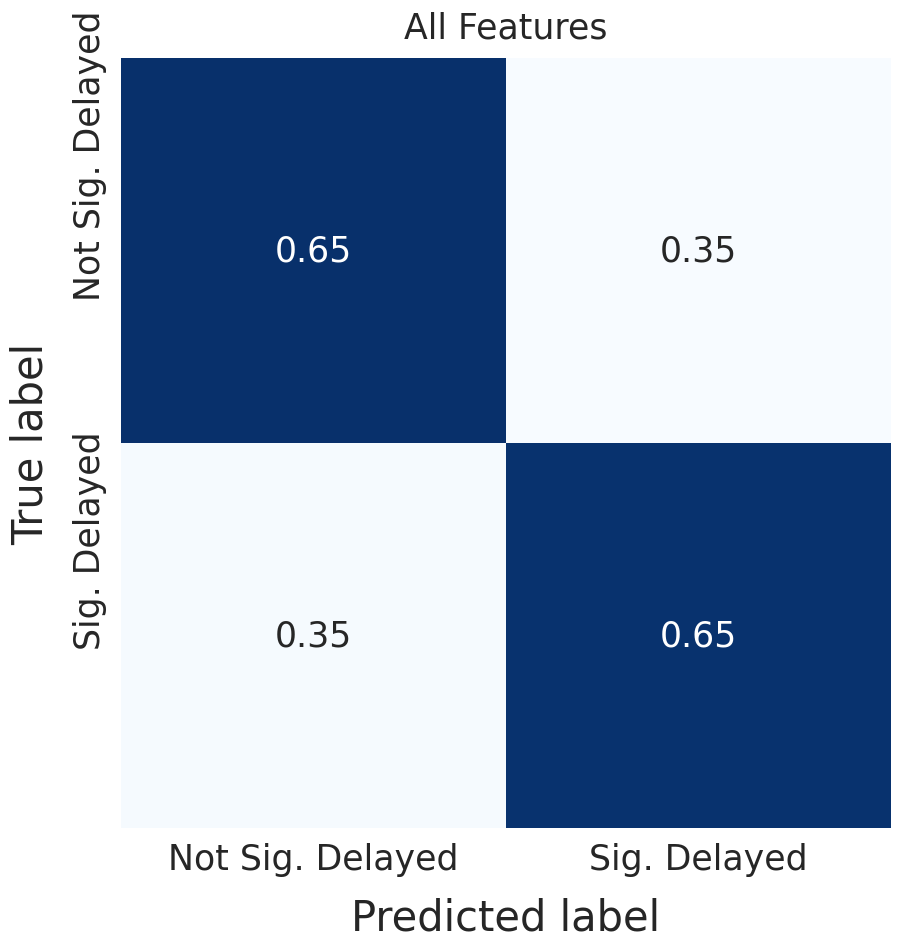

In [27]:
year = '2024-01'
for name,df in df_simultaneousClassification_tuned.items():
    # Convert 'Removed' column from boolean to integers (True/False -> 1/0) [ADDED THIS BECAUSE OF ERROR]
    df['target_binary'] = df['target_binary'].astype(int)

    y_test, y_predict = df[df['YearMonth']==year][['target_binary','simultaneous_pred']].values.T
    cm = confusion_matrix(y_test, y_predict)
    cm = cm.astype('float') / cm.sum(axis = 1)[:,None]
    fig,ax = plt.subplots(figsize=(10,10))
    plt.title(f"{name}", fontsize=25)
    pure_plot_confusion_matrix(cm, ax=ax)
    file_path = results_xgb_plots / f"TUNED_XGB_CM_Sim_Allf.png"
    
    # Save the figure before showing it to prevent canvas flushing
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

In [28]:
from datetime import datetime,date
from collections import defaultdict

# Assuming df_simultaneousClassification is already defined
year_list_tuned = df_simultaneousClassification_ALLF_tuned.YearMonth.unique()
balanced_acc_tuned = defaultdict(list)

for name, df in df_simultaneousClassification_tuned.items():
	for year in year_list_tuned:
		period_year = pd.Period(year, freq='M')
		y_test, y_predict, y_null = df[df.YearMonth == year][['target_binary', 'simultaneous_pred', 'simultaneous_null']].values.T
		balanced_acc_tuned['Balanced Acc'].append(balanced_accuracy_score(y_test, y_predict))
		balanced_acc_tuned['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))
		balanced_acc_tuned['Model'].append(name)
	

In [29]:
df = pd.DataFrame(balanced_acc_tuned)
df = df.groupby('Model', sort=False).mean()
df

,Balanced Acc,Balanced Acc Null
Model,,
All Features,0.631245,0.495036


### Results from all classifiers 



Here we will show the results from running 1b_Classification.py that are in folder results_classifiers.

In [30]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score
from IPython.display import display

# Function to extract metrics for simultaneous testing
def extract_simultaneous_metrics(results_dir):
    results = []
    for file_name in os.listdir(results_dir):
        if file_name.endswith('_results.csv') and 'nonsimultaneous' not in file_name:
            # Split the file name correctly to get the classifier name and feature set
            classifier_name, feature_set = file_name.replace('_results.csv', '').rsplit('_', 1)
            file_path = os.path.join(results_dir, file_name)
            df = pd.read_csv(file_path)

            # Check if required columns exist
            pred_column = f'{classifier_name}_{feature_set}_pred'
            proba_column = f'{classifier_name}_{feature_set}_proba'
            if pred_column in df.columns and proba_column in df.columns:
                y_true = df['target_binary'].astype(int).tolist()
                y_pred = df[pred_column].astype(int).tolist()
                y_proba = df[proba_column].tolist()

                if len(y_true) > 0 and len(y_pred) > 0:
                    y_true = pd.Series(y_true).astype(int)
                    y_pred = pd.Series(y_pred).astype(int)
                    if y_proba and not any(np.isnan(y_proba)):
                        y_proba = pd.Series(y_proba)
                        auc = roc_auc_score(y_true, y_proba)
                    else:
                        auc = np.nan
                    
                    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
                    f1 = f1_score(y_true, y_pred)

                    results.append({
                        'Classifier': classifier_name,
                        'Feature Set': feature_set,
                        'Balanced Accuracy': balanced_accuracy,
                        'F1 Score': f1,
                        'ROC AUC': auc
                    })
                else:
                    results.append({
                        'Classifier': classifier_name,
                        'Feature Set': feature_set,
                        'Balanced Accuracy': np.nan,
                        'F1 Score': np.nan,
                        'ROC AUC': np.nan
                    })
            else:
                print(f"Pred/Proba columns not found in {file_name}")
    return pd.DataFrame(results)

# --- Define desired column order based on exact abbreviations ---
feature_order = [
    'TOP',   # Topological Features
    'WGT',   # Weight Features
    'WTH',   # Weather Features
    'OPS',   # Operational Features
    # 'CAL',   # Calendar Features
    'TW',    # Topological + Weight
    # 'TWC',   # Topological + Weight + Calendar
    'TWCW',  # Topological + Weight + Weather
    'TWCO',  # Topological + Weight + Operational
    'ALLF'   # All Features
]

# --- Helper function to safely pivot and reorder columns ---
def pivot_and_reorder(df, values_col, order):
    pivot_df = df.pivot(index='Classifier', columns='Feature Set', values=values_col)
    
    # Filter to only columns that actually exist in the data to prevent KeyErrors
    ordered_cols = [col for col in order if col in pivot_df.columns]
    
    # Append any unexpected/extra columns to the end just in case
    extra_cols = [col for col in pivot_df.columns if col not in order]
    
    return pivot_df[ordered_cols + extra_cols]


# ==============================================================================
# 1. DEFAULT HPARAM + NO CLASS WEIGHTS
# ==============================================================================

# Extract the metrics for simultaneous testing
simultaneous_df = extract_simultaneous_metrics(results_classifiers_DEF_NCW)

# Create and reorder separate tables for each metric
simultaneous_bal_acc_df = pivot_and_reorder(simultaneous_df, 'Balanced Accuracy', feature_order)
simultaneous_f1_df = pivot_and_reorder(simultaneous_df, 'F1 Score', feature_order)
simultaneous_roc_auc_df = pivot_and_reorder(simultaneous_df, 'ROC AUC', feature_order)

# Display the tables
print("Simultaneous Testing Balanced Accuracy Results:")
display(simultaneous_bal_acc_df)

print("\nSimultaneous Testing F1 Score Results:")
display(simultaneous_f1_df)

print("\nSimultaneous Testing ROC AUC Results:")
display(simultaneous_roc_auc_df)


# # ==============================================================================
# # 2. DEFAULT HPARAM + CLASS WEIGHTS
# # ==============================================================================

# # Extract the metrics for simultaneous testing
# simultaneous_df_DEF_NCW = extract_simultaneous_metrics(results_dir)

# # Create and reorder separate tables for each metric
# simultaneous_bal_acc_df_DEF_NCW = pivot_and_reorder(simultaneous_df_DEF_NCW, 'Balanced Accuracy', feature_order)
# simultaneous_f1_df_DEF_NCW = pivot_and_reorder(simultaneous_df_DEF_NCW, 'F1 Score', feature_order)
# simultaneous_roc_auc_df_DEF_NCW = pivot_and_reorder(simultaneous_df_DEF_NCW, 'ROC AUC', feature_order)

# # Display the tables
# print("\nSimultaneous Testing Balanced Accuracy Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(simultaneous_bal_acc_df_DEF_NCW)

# print("\nSimultaneous Testing F1 Score Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(simultaneous_f1_df_DEF_NCW)

# print("\nSimultaneous Testing ROC AUC Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(simultaneous_roc_auc_df_DEF_NCW)

Simultaneous Testing Balanced Accuracy Results:


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.639816,0.677287,0.635729,0.638304,0.683899,0.693816,0.691173,0.700059
LogisticRegression,0.584370,0.606772,0.567950,0.588591,0.602791,0.622760,0.626992,0.641004
RandomForestClassifier,0.681630,0.698163,0.662032,0.674439,0.708541,0.711877,0.712622,0.720383
XGBClassifier,0.643037,0.681697,0.642125,0.648854,0.679725,0.690711,0.691379,0.695187



Simultaneous Testing F1 Score Results:


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.641600,0.676051,0.633031,0.637732,0.685945,0.694307,0.692951,0.701996
LogisticRegression,0.557839,0.579335,0.569088,0.543417,0.581408,0.619109,0.608720,0.634528
RandomForestClassifier,0.680515,0.698941,0.659169,0.677639,0.707538,0.710771,0.711991,0.720390
XGBClassifier,0.642025,0.677319,0.638662,0.644586,0.680179,0.689627,0.690298,0.694178



Simultaneous Testing ROC AUC Results:


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.698928,0.744887,0.696542,0.699893,0.750104,0.765188,0.760110,0.774680
LogisticRegression,0.609094,0.651693,0.591396,0.636151,0.645655,0.670435,0.677973,0.693428
RandomForestClassifier,0.733753,0.765706,0.723676,0.739981,0.770375,0.779054,0.782466,0.791710
XGBClassifier,0.698938,0.744486,0.696649,0.706431,0.743947,0.754798,0.756689,0.763679


## Non Simultaneous Testing

In [31]:
xgb_results_folder_path = results_xgb

# Loop through the directory, check if it's a file (not a sub-folder), and get the name
file_names = [f.name for f in xgb_results_folder_path.iterdir() if f.is_file()]
print(file_names)

# The asterisk (*) is a (regex) wildcard. This grabs ONLY .csv files.
csv_files = [f.name for f in xgb_results_folder_path.glob("*nonsimultaneous.pkl")]

print(csv_files)


['balanced_acc_non.pkl', 'NS_C_ALLF_nonsimultaneous.pkl', 'NS_C_ALLF_SHAP.pkl', 'NS_C_ALLF_simultaneous.csv', 'NS_C_TWCO_nonsimultaneous.pkl', 'NS_C_TWCO_SHAP.pkl', 'NS_C_TWCO_simultaneous.csv', 'NS_C_TWCW_nonsimultaneous.pkl', 'NS_C_TWCW_SHAP.pkl', 'NS_C_TWCW_simultaneous.csv', 'NS_C_TW_nonsimultaneous.pkl', 'NS_C_TW_SHAP.pkl', 'NS_C_TW_simultaneous.csv', 'NS_I_OPS_nonsimultaneous.pkl', 'NS_I_OPS_SHAP.pkl', 'NS_I_OPS_simultaneous.csv', 'NS_I_TOP_nonsimultaneous.pkl', 'NS_I_TOP_SHAP.pkl', 'NS_I_TOP_simultaneous.csv', 'NS_I_WGT_nonsimultaneous.pkl', 'NS_I_WGT_SHAP.pkl', 'NS_I_WGT_simultaneous.csv', 'NS_I_WTH_nonsimultaneous.pkl', 'NS_I_WTH_SHAP.pkl', 'NS_I_WTH_simultaneous.csv']
['NS_C_ALLF_nonsimultaneous.pkl', 'NS_C_TWCO_nonsimultaneous.pkl', 'NS_C_TWCW_nonsimultaneous.pkl', 'NS_C_TW_nonsimultaneous.pkl', 'NS_I_OPS_nonsimultaneous.pkl', 'NS_I_TOP_nonsimultaneous.pkl', 'NS_I_WGT_nonsimultaneous.pkl', 'NS_I_WTH_nonsimultaneous.pkl']


In [32]:
import pandas as pd

# ## Individual sets
df_nonsimultaneousClassification_TOP = pd.read_pickle(f"{results_xgb}/NS_I_TOP_nonsimultaneous.pkl")
df_nonsimultaneousClassification_WGT = pd.read_pickle(f"{results_xgb}/NS_I_WGT_nonsimultaneous.pkl")
df_nonsimultaneousClassification_WTH = pd.read_pickle(f"{results_xgb}/NS_I_WTH_nonsimultaneous.pkl")
df_nonsimultaneousClassification_OPS = pd.read_pickle(f"{results_xgb}/NS_I_OPS_nonsimultaneous.pkl")
# df_nonsimultaneousClassification_CAL = pd.read_pickle(f"{results_xgb}/NS_I_CAL_nonsimultaneous.pkl")

# ## Intermediate 
df_nonsimultaneousClassification_TW = pd.read_pickle(f"{results_xgb}/NS_C_TW_nonsimultaneous.pkl")

# ## Combined sets
# df_nonsimultaneousClassification_TWC = pd.read_pickle(f"{results_xgb}/NS_C_TWC_nonsimultaneous.pkl")
df_nonsimultaneousClassification_TWCW = pd.read_pickle(f"{results_xgb}/NS_C_TWCW_nonsimultaneous.pkl")
df_nonsimultaneousClassification_TWCO = pd.read_pickle(f"{results_xgb}/NS_C_TWCO_nonsimultaneous.pkl")
df_nonsimultaneousClassification_ALLF = pd.read_pickle(f"{results_xgb}/NS_C_ALLF_nonsimultaneous.pkl")


In [33]:
# df_nonsimultaneousClassification = {'Unweighted Topological Features': df_nonsimultaneousClassification_BTF,
#                                      'Weighted Topological Features': df_nonsimultaneousClassification_WTF,
#                                      'Node Centrality Measures': df_nonsimultaneousClassification_NCM}

In [34]:
# ## Dictionary Mapping
df_nonsimultaneousClassification = {
    'Topological Features': df_nonsimultaneousClassification_TOP,
    'Weight Features': df_nonsimultaneousClassification_WGT,
    'Weather Features': df_nonsimultaneousClassification_WTH,
    'Operational Features': df_nonsimultaneousClassification_OPS,
    # 'Calendar Features': df_nonsimultaneousClassification_CAL,
    
    'Topological + Weight': df_nonsimultaneousClassification_TW,
    
    # 'Topological + Weight + Calendar': df_nonsimultaneousClassification_TWC,
    'Topological + Weight + Weather': df_nonsimultaneousClassification_TWCW,
    'Topological + Weight + Operational': df_nonsimultaneousClassification_TWCO,
    'All Features': df_nonsimultaneousClassification_ALLF
}

### CM XGB Nonsim

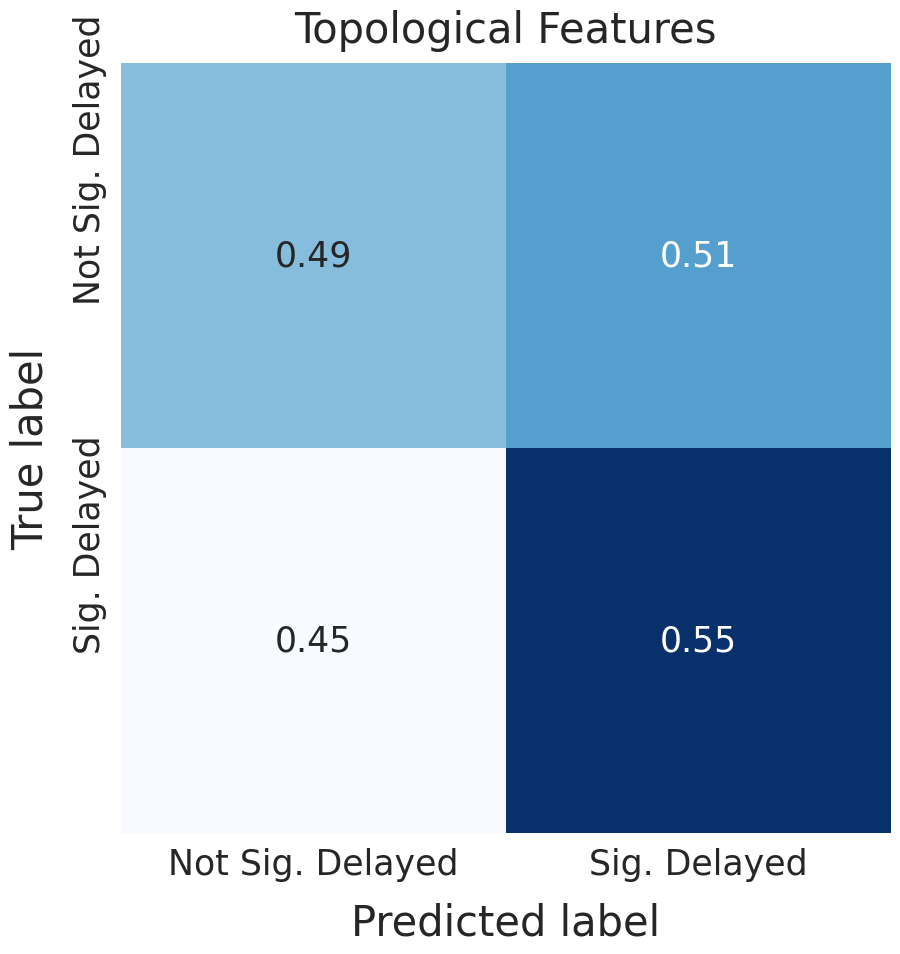

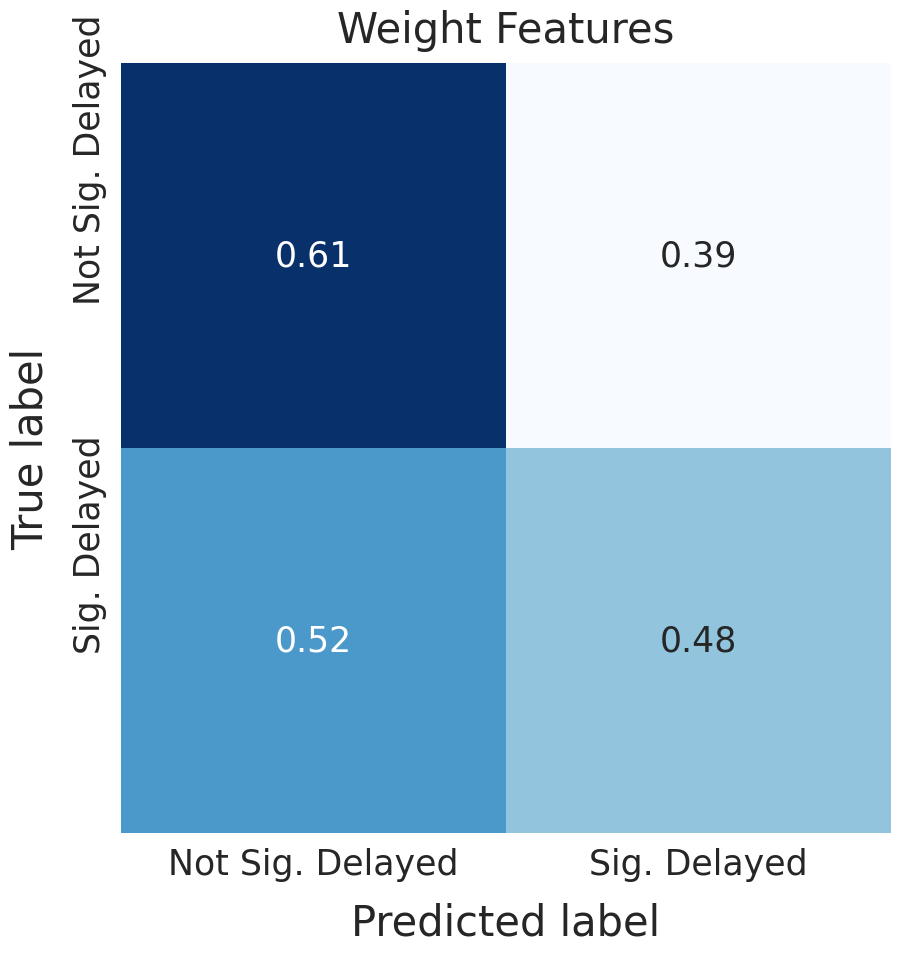

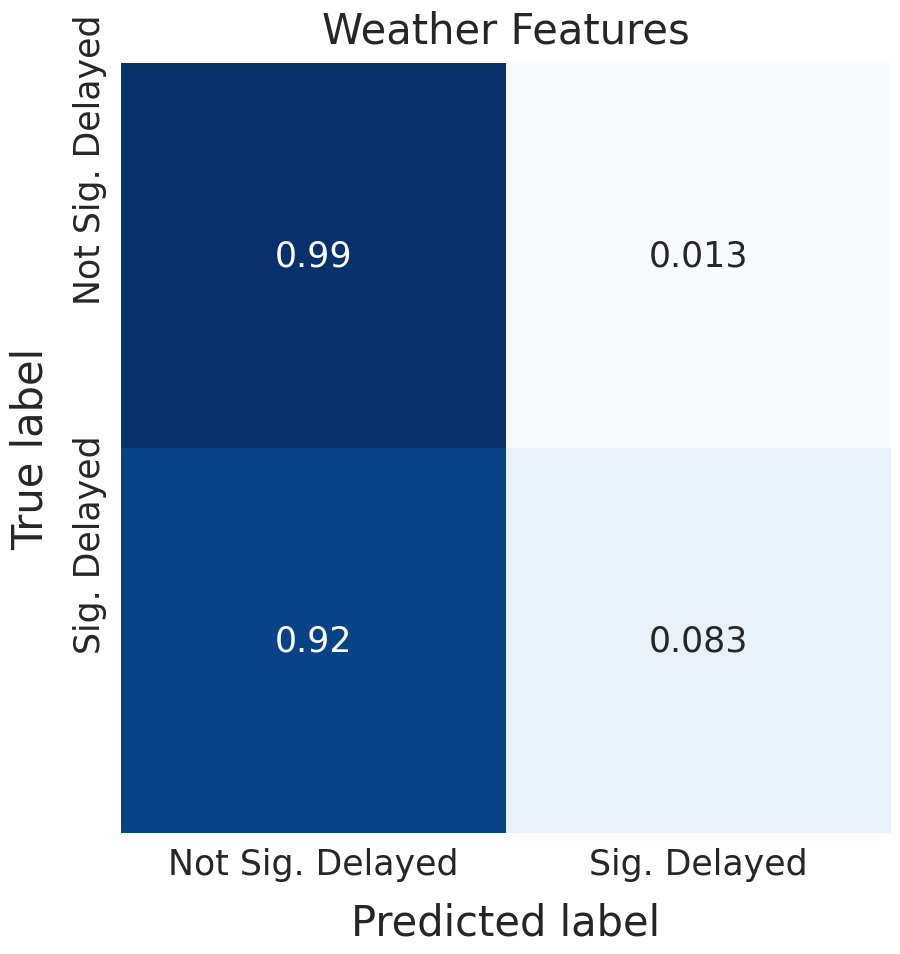

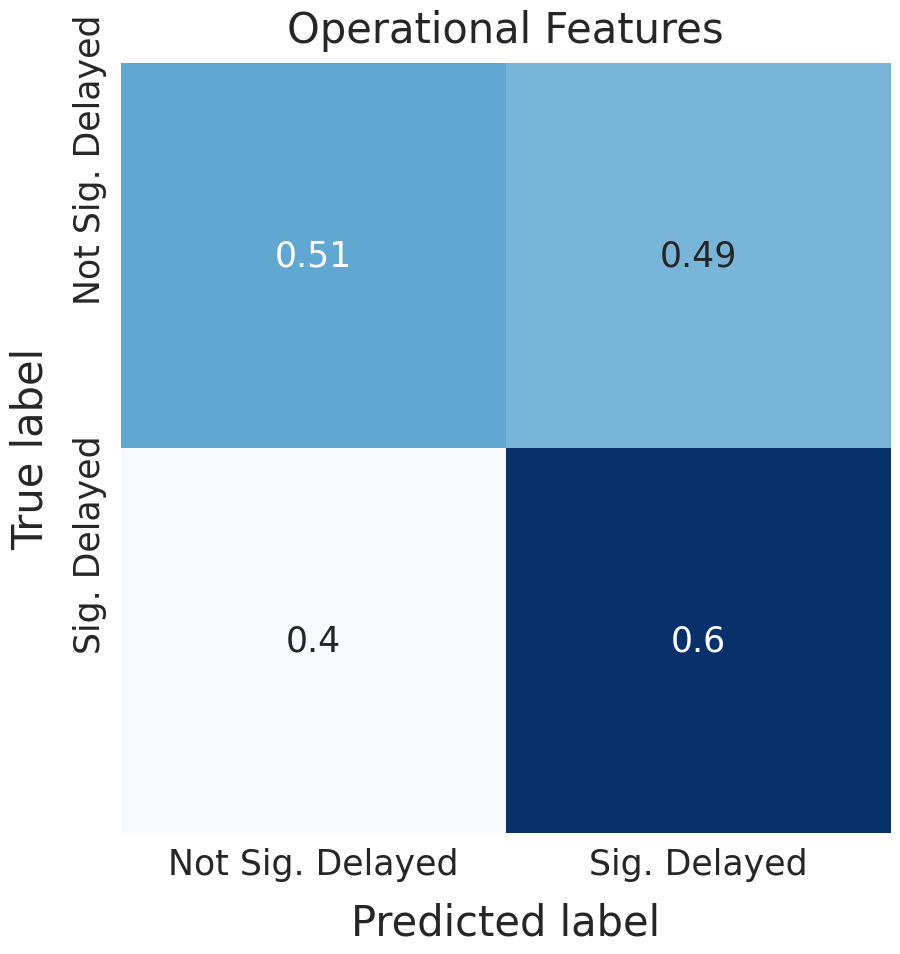

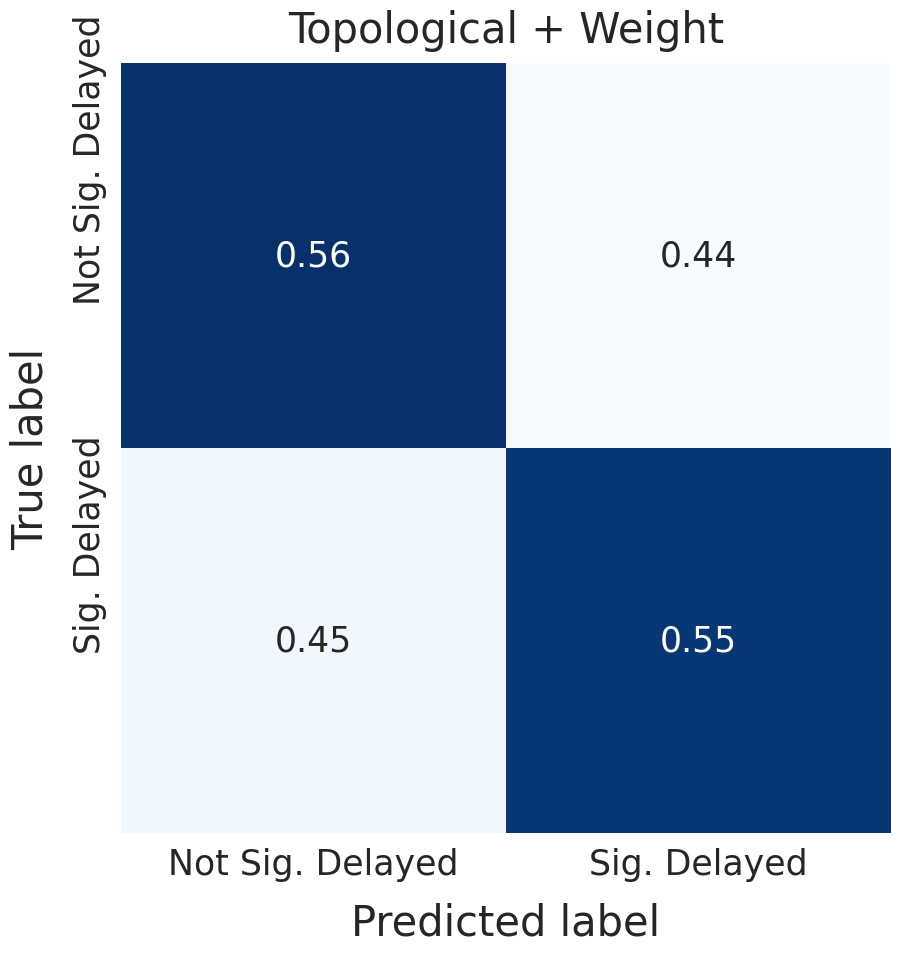

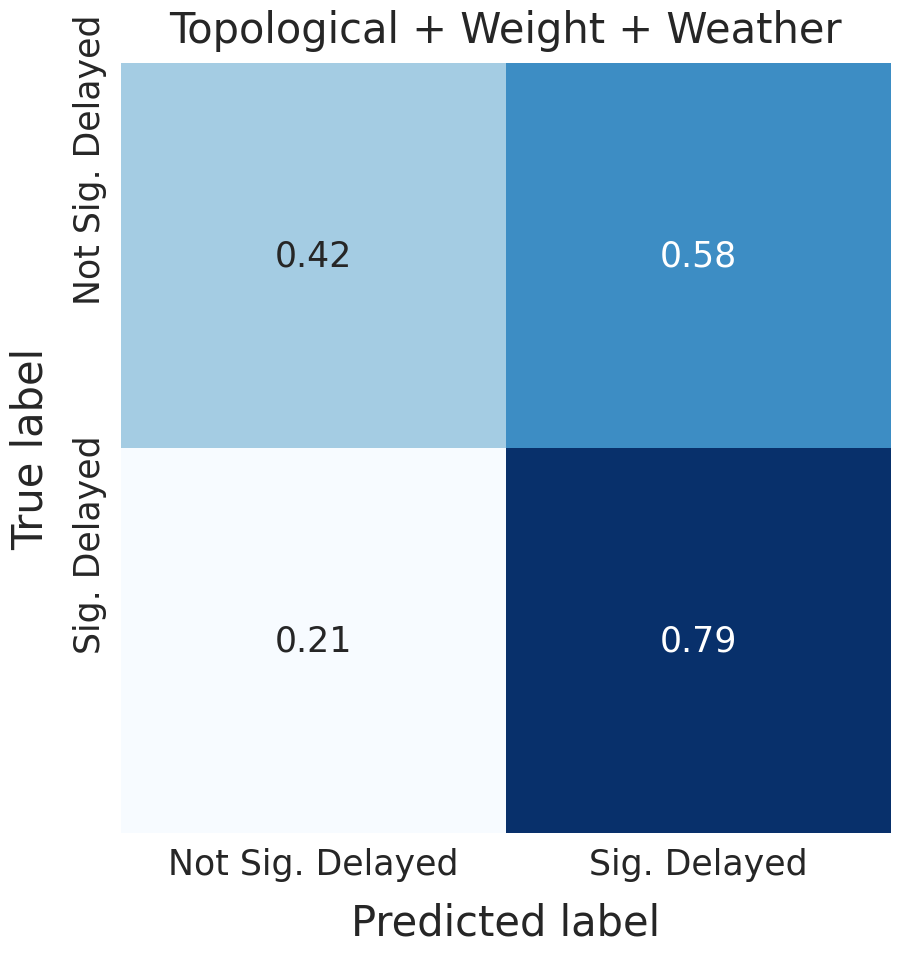

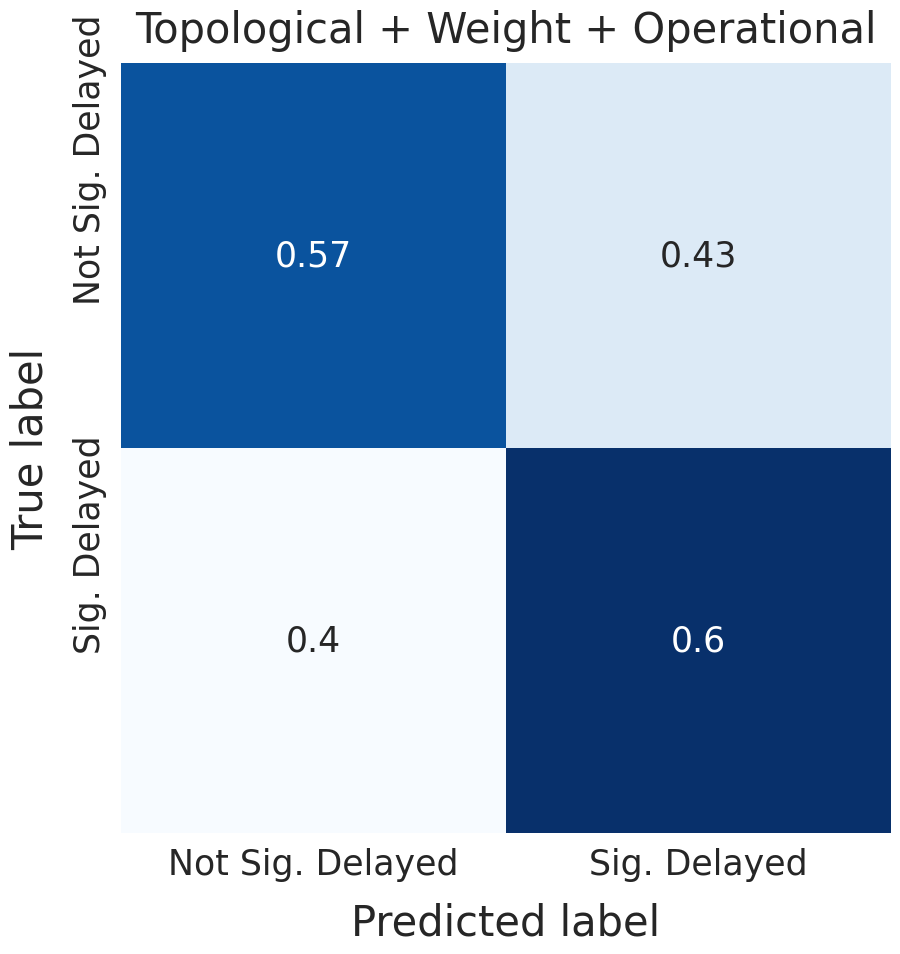

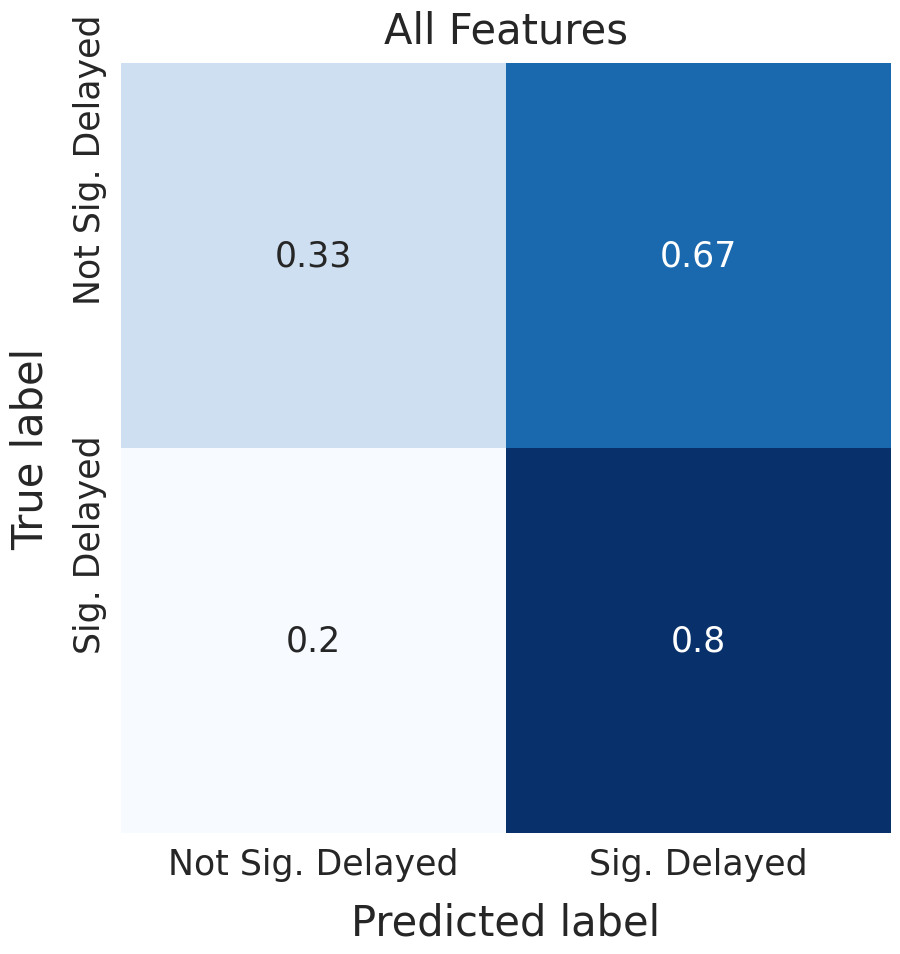

In [35]:
name_to_suffix = {
    'Topological Features': 'Top',
    'Weight Features': 'Wgt',
    'Weather Features': 'Wth',
    'Operational Features': 'Ops',
    'Topological + Weight': 'Tw',
    'Topological + Weight + Weather': 'Twcw',
    'Topological + Weight + Operational': 'Twco',
    'All Features': 'Allf'
}

year0 = pd.Period('2024-01', freq='M')
year1 = pd.Period('2024-03', freq='M')

for name, df in df_nonsimultaneousClassification.items():
    for year_train, year_test, y_test_data, y_pred_data, y_null_data in df:
        period_year_train = pd.Period(year_train, freq='M')
        period_year_test = pd.Period(year_test, freq='M')
        
        if period_year_train == year0 and period_year_test == year1:
            # Variables are explicitly reassigned to prevent scope leakage issues 
            # from the completed loop.
            y_test = y_test_data
            y_predict = y_pred_data
            break

    cm = confusion_matrix(y_test, y_predict)
    cm = cm.astype('float') / cm.sum(axis=1)[:, None]
    
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.title(f"{name}", fontsize=30)
    pure_plot_confusion_matrix(cm, ax=ax)
    
    # The abbreviation suffix is extracted to construct the precise target file path.
    suffix = name_to_suffix.get(name, "Unknown")
    file_path = results_xgb_plots / f"Base_XGB_CM_NonSim_{suffix}.png"
    
    # The figure is exported prior to display to ensure the data buffer is not emptied.
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

### Balanced accuracy XGB Null

(takes approx 1:30 minute, comment if, leave else to recalculate)

In [36]:
file_path = results_xgb / "balanced_acc_non.pkl"

if file_path.exists():
    balanced_acc_non = pd.read_pickle(file_path)
    # If the dictionary format is strictly required downstream, it can be converted back:
    # balanced_acc_non = balanced_acc_non_df.to_dict('list')
else:
    balanced_acc_non = defaultdict(list)
    
    for name, df in df_nonsimultaneousClassification.items():
        for year_train, year_test, y_test, y_pred, y_null in df:
            period_year_train = pd.Period(year_train, freq='M')
            period_year_test = pd.Period(year_test, freq='M')

            if period_year_train != period_year_test and period_year_train < pd.Period('2024-01', freq='M'):
                balanced_acc_non['Balanced Acc'].append(balanced_accuracy_score(y_test, y_pred))
                balanced_acc_non['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))
                balanced_acc_non['Model'].append(name)

    # Convert balanced_acc_non to a DataFrame for easier handling and storage
    balanced_acc_non_df = pd.DataFrame(balanced_acc_non)
    balanced_acc_non_df.to_pickle(file_path)

In [37]:
df = pd.DataFrame(balanced_acc_non)
df = df.groupby(['Model'], sort=False).mean()
df

,Balanced Acc,Balanced Acc Null
Model,,
Topological Features,0.561000,0.502868
Weight Features,0.562787,0.508337
Weather Features,0.499632,0.500794
Operational Features,0.523176,0.507975
Topological + Weight,0.571135,0.507904
Topological + Weight + Weather,0.555370,0.514632
Topological + Weight + Operational,0.571522,0.498210
All Features,0.564713,0.495940


### XGB Tuned (allfeatures set sanity check)

In [38]:
xgb_results_hparam_folder_path = results_xgb_hparam

# Loop through the directory, check if it's a file (not a sub-folder), and get the name
file_names = [f.name for f in xgb_results_hparam_folder_path.iterdir() if f.is_file()]
print(file_names)

# The asterisk (*) is a (regex) wildcard. This grabs ONLY .csv files.
csv_files = [f.name for f in xgb_results_hparam_folder_path.glob("*nonsimultaneous.pkl")]

print(csv_files)

df_nonsimultaneousClassification_ALLF_tuned = pd.read_pickle(f"{xgb_results_hparam_folder_path}/NS_C_ALLF_TUNED_nonsimultaneous.pkl")


df_nonsimultaneousClassification_tuned = {
	'All Features': df_nonsimultaneousClassification_ALLF_tuned
}


['NS_C_ALLF_TUNED_nonsimultaneous.pkl', 'NS_C_ALLF_TUNED_simultaneous.csv']
['NS_C_ALLF_TUNED_nonsimultaneous.pkl']


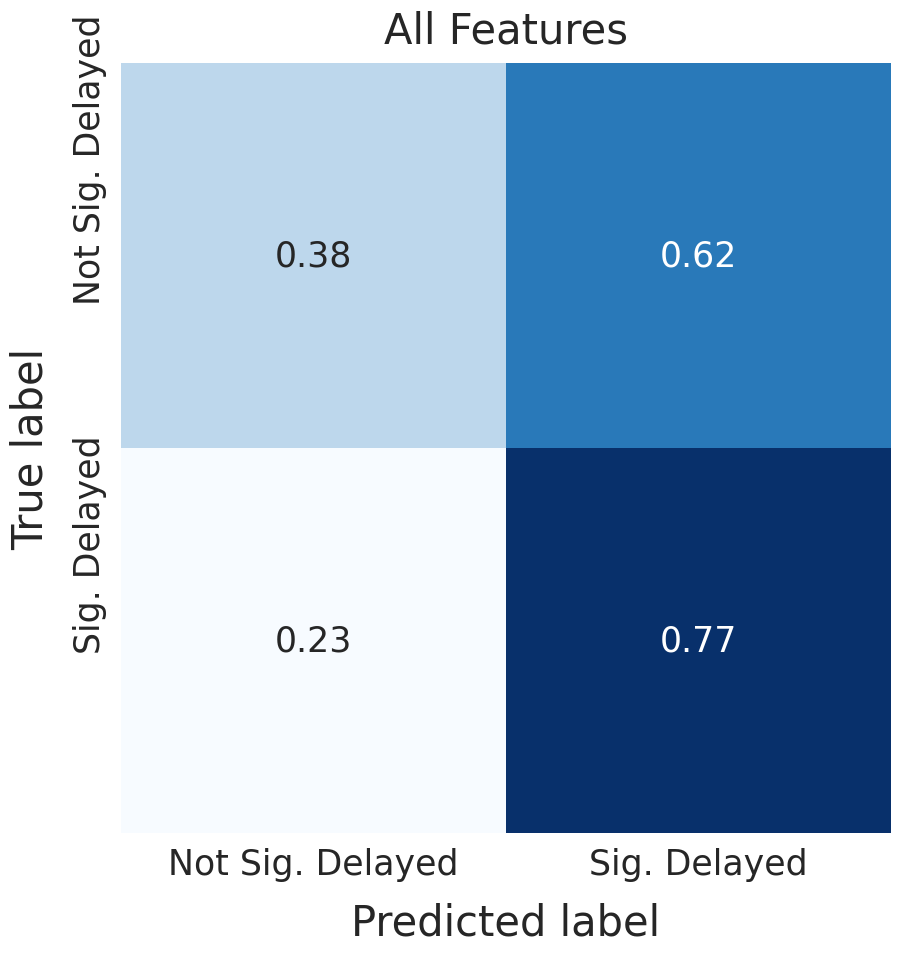

In [39]:
year0 = pd.Period('2024-01', freq='M')
year1 = pd.Period('2024-03', freq='M')

for name, df in df_nonsimultaneousClassification_tuned.items():
	for year_train, year_test, y_test, y_pred, y_null in df:
		period_year_train = pd.Period(year_train, freq='M')
		period_year_test = pd.Period(year_test, freq='M')
		
		if period_year_train == year0 and period_year_test == year1:
			break

	y_test, y_predict = y_test, y_pred
	cm = confusion_matrix(y_test, y_predict)
	cm = cm.astype('float') / cm.sum(axis=1)[:, None]
	
	fig, ax = plt.subplots(figsize=(10, 10))
	plt.title(f"{name}", fontsize=30)
	pure_plot_confusion_matrix(cm, ax=ax)
	file_path = results_xgb_plots / f"TUNED_XGB_CM_NonSim_Allf.png"
	
	# Save the figure before showing it to prevent canvas flushing
	plt.savefig(file_path, bbox_inches='tight', dpi=300)
	plt.show()

In [40]:
balanced_acc_non_tuned = defaultdict(list)
for name, df in df_nonsimultaneousClassification_tuned.items():
    for year_train, year_test, y_test, y_pred, y_null in df:
        period_year_train = pd.Period(year_train, freq='M')
        period_year_test = pd.Period(year_test, freq='M')

        if period_year_train != period_year_test and period_year_train < pd.Period('2024-01', freq='M'):
            balanced_acc_non_tuned['Balanced Acc'].append(balanced_accuracy_score(y_test, y_pred))
            balanced_acc_non_tuned['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))
            balanced_acc_non_tuned['Model'].append(name)

# Optionally convert balanced_acc_non to a DataFrame for easier handling
balanced_acc_non_df_tuned = pd.DataFrame(balanced_acc_non_tuned)

In [41]:
# new
df = pd.DataFrame(balanced_acc_non_tuned)
df = df.groupby(['Model'], sort=False).mean()
df

,Balanced Acc,Balanced Acc Null
Model,,
All Features,0.561052,0.501332


### Results from all classifiers 


Here we will show the results from running 1b_Classification.py that are in the results_classifiers folder.
5min~

Run else part if recalculation required

In [42]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score
from IPython.display import display

# Function to extract metrics for non-simultaneous testing (UNCHANGED)
def extract_nonsimultaneous_metrics(results_dir):
    results = []
    for file_name in os.listdir(results_dir):
        if file_name.endswith('_nonsimultaneous_results.csv'):
            classifier_name, feature_set = file_name.replace('_nonsimultaneous_results.csv', '').rsplit('_', 1)
            file_path = os.path.join(results_dir, file_name)
            df = pd.read_csv(file_path)

            y_true = []
            y_pred = []
            y_proba = []
            for _, row in df.iterrows():
                y_true.extend(eval(row['TrueLabels']))
                y_pred.extend(eval(row['Predictions']))
                y_proba.extend(eval(row['Probabilities']))

            if len(y_true) > 0 and len(y_pred) > 0:
                y_true = pd.Series(y_true).astype(int)
                y_pred = pd.Series(y_pred).astype(int)
                if y_proba:
                    y_proba = pd.Series(y_proba)
                    auc = roc_auc_score(y_true, y_proba)
                else:
                    auc = np.nan
                
                balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)

                results.append({
                    'Classifier': classifier_name,
                    'Feature Set': feature_set,
                    'Balanced Accuracy': balanced_accuracy,
                    'F1 Score': f1,
                    'ROC AUC': auc
                })
            else:
                results.append({
                    'Classifier': classifier_name,
                    'Feature Set': feature_set,
                    'Balanced Accuracy': np.nan,
                    'F1 Score': np.nan,
                    'ROC AUC': np.nan
                })
    return pd.DataFrame(results)

# --- Define your desired column order based on your exact abbreviations ---
feature_order = [
    'TOP',   # Topological Features
    'WGT',   # Weight Features
    'WTH',   # Weather Features
    'OPS',   # Operational Features
    # 'CAL',   # Calendar Features
    'TW',    # Topological + Weight
    # 'TWC',   # Topological + Weight + Calendar
    'TWCW',  # Topological + Weight + Calendar + Weather
    'TWCO',  # Topological + Weight + Calendar + Operational
    'ALLF'   # All Features
]

# --- Helper function to safely pivot and reorder columns ---
def pivot_and_reorder(df, values_col, order):
    pivot_df = df.pivot(index='Classifier', columns='Feature Set', values=values_col)
    
    # Filter to only columns that actually exist in the data to prevent KeyErrors
    ordered_cols = [col for col in order if col in pivot_df.columns]
    
    # Append any unexpected/extra columns to the end just in case
    extra_cols = [col for col in pivot_df.columns if col not in order]
    
    return pivot_df[ordered_cols + extra_cols]


# ==============================================================================
# 1. DEFAULT HPARAM + NO CLASS WEIGHTS
# ==============================================================================

# nonsimultaneous_df = extract_nonsimultaneous_metrics(results_classifiers_DEF_NCW)

# # Create and reorder separate tables for each metric
# nonsimultaneous_bal_acc_df = pivot_and_reorder(nonsimultaneous_df, 'Balanced Accuracy', feature_order)
# nonsimultaneous_f1_df = pivot_and_reorder(nonsimultaneous_df, 'F1 Score', feature_order)
# nonsimultaneous_roc_auc_df = pivot_and_reorder(nonsimultaneous_df, 'ROC AUC', feature_order)

# print("Non-Simultaneous Testing Balanced Accuracy Results :")
# display(nonsimultaneous_bal_acc_df)

# print("\nNon-Simultaneous Testing F1 Score Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(nonsimultaneous_f1_df)

# print("\nNon-Simultaneous Testing ROC AUC Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(nonsimultaneous_roc_auc_df)

# Define file paths for the saved pickle files
base_df_path = results_classifiers_DEF_NCW / 'nonsimultaneous_df.pkl'
bal_acc_path = results_classifiers_DEF_NCW / 'nonsimultaneous_bal_acc_df.pkl'
f1_path = results_classifiers_DEF_NCW / 'nonsimultaneous_f1_df.pkl'
roc_auc_path = results_classifiers_DEF_NCW / 'nonsimultaneous_roc_auc_df.pkl'

# Check if the calculated files already exist
if (os.path.exists(base_df_path) and os.path.exists(bal_acc_path) and 
    os.path.exists(f1_path) and os.path.exists(roc_auc_path)):
    
    # Load the data and skip the heavy extraction
    print("Loading pre-calculated DataFrames from pickle files...")
    nonsimultaneous_df = pd.read_pickle(base_df_path)
    nonsimultaneous_bal_acc_df = pd.read_pickle(bal_acc_path)
    nonsimultaneous_f1_df = pd.read_pickle(f1_path)
    nonsimultaneous_roc_auc_df = pd.read_pickle(roc_auc_path)

else:
    print("No saved files found. Running extraction and calculations...")
    
    # Run the heavy extraction step
    nonsimultaneous_df = extract_nonsimultaneous_metrics(results_classifiers_DEF_NCW)

    # Create and reorder separate tables for each metric
    nonsimultaneous_bal_acc_df = pivot_and_reorder(nonsimultaneous_df, 'Balanced Accuracy', feature_order)
    nonsimultaneous_f1_df = pivot_and_reorder(nonsimultaneous_df, 'F1 Score', feature_order)
    nonsimultaneous_roc_auc_df = pivot_and_reorder(nonsimultaneous_df, 'ROC AUC', feature_order)
    
    # Save the base DataFrame and the pivoted tables to disk
    nonsimultaneous_df.to_pickle(base_df_path)
    nonsimultaneous_bal_acc_df.to_pickle(bal_acc_path)
    nonsimultaneous_f1_df.to_pickle(f1_path)
    nonsimultaneous_roc_auc_df.to_pickle(roc_auc_path)
    print("Calculations complete. DataFrames saved to disk.")

# Display results
print("\nNon-Simultaneous Testing Balanced Accuracy Results :")
display(nonsimultaneous_bal_acc_df)

print("\nNon-Simultaneous Testing F1 Score Results (DEFAULT HPARAM + CLASS WEIGHTS):")
display(nonsimultaneous_f1_df)

print("\nNon-Simultaneous Testing ROC AUC Results (DEFAULT HPARAM + CLASS WEIGHTS):")
display(nonsimultaneous_roc_auc_df)

# ==============================================================================
# 2. DEFAULT HPARAM + CLASS WEIGHTS
# ==============================================================================

# nonsimultaneous_df_DEF_NCW = extract_nonsimultaneous_metrics(results_dir)

# # Create and reorder separate tables for each metric
# nonsimultaneous_bal_acc_df_DEF_NCW = pivot_and_reorder(nonsimultaneous_df_DEF_NCW, 'Balanced Accuracy', feature_order)
# nonsimultaneous_f1_df_DEF_NCW = pivot_and_reorder(nonsimultaneous_df_DEF_NCW, 'F1 Score', feature_order)
# nonsimultaneous_roc_auc_df_DEF_NCW = pivot_and_reorder(nonsimultaneous_df_DEF_NCW, 'ROC AUC', feature_order)

# print("\nNon-Simultaneous Testing Balanced Accuracy Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(nonsimultaneous_bal_acc_df_DEF_NCW)

# print("\nNon-Simultaneous Testing F1 Score Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(nonsimultaneous_f1_df_DEF_NCW)

# print("\nNon-Simultaneous Testing ROC AUC Results (DEFAULT HPARAM + CLASS WEIGHTS):")
# display(nonsimultaneous_roc_auc_df_DEF_NCW)

Loading pre-calculated DataFrames from pickle files...

Non-Simultaneous Testing Balanced Accuracy Results :


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.592937,0.583508,0.499006,0.557728,0.596883,0.556751,0.602244,0.564135
LogisticRegression,0.546147,0.551735,0.490021,0.565760,0.551210,0.498472,0.577077,0.505669
RandomForestClassifier,0.591818,0.578005,0.502465,0.556337,0.590055,0.536795,0.593819,0.542990
XGBClassifier,0.594279,0.580730,0.499428,0.556383,0.595766,0.557522,0.601779,0.564859



Non-Simultaneous Testing F1 Score Results (DEFAULT HPARAM + CLASS WEIGHTS):


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.596898,0.579287,0.469452,0.552700,0.597444,0.573076,0.600768,0.571533
LogisticRegression,0.518180,0.521454,0.546164,0.520922,0.533045,0.561464,0.559802,0.557031
RandomForestClassifier,0.588686,0.574700,0.489241,0.552907,0.583448,0.532896,0.587910,0.529456
XGBClassifier,0.595047,0.572308,0.495759,0.546467,0.593841,0.572488,0.597573,0.570282



Non-Simultaneous Testing ROC AUC Results (DEFAULT HPARAM + CLASS WEIGHTS):


Feature Set,TOP,WGT,WTH,OPS,TW,TWCW,TWCO,ALLF
Classifier,,,,,,,,
LGBMClassifier,0.619804,0.610186,0.499647,0.576657,0.623963,0.577402,0.630671,0.585998
LogisticRegression,0.565307,0.582276,0.482763,0.570800,0.580113,0.491934,0.606508,0.499224
RandomForestClassifier,0.615330,0.606271,0.503750,0.575434,0.620303,0.555268,0.624060,0.564176
XGBClassifier,0.620858,0.609353,0.500593,0.574594,0.623705,0.577813,0.630852,0.588027


## Metrics

tlmgr install type1cm cm-super

In [43]:
def stdrcparams(usetex=True):
	rcparams = {
		'font.family': 'sans-serif',
		'font.sans-serif': ['Helvetica'],
		'text.usetex': usetex,
		'axes.labelsize': 12,
		'font.size': 12,
		'legend.fontsize': 12,
		'xtick.labelsize': 12,
		'ytick.labelsize': 12,
	}
	if usetex:
		rcparams['text.latex.preamble'] = r'\usepackage{amsmath}'
	mpl.rcParams.update(rcparams)
	
# Define plot dimensions
xs = 8  # width of the plot
ys = 5   # height of the plot

### Boxplots

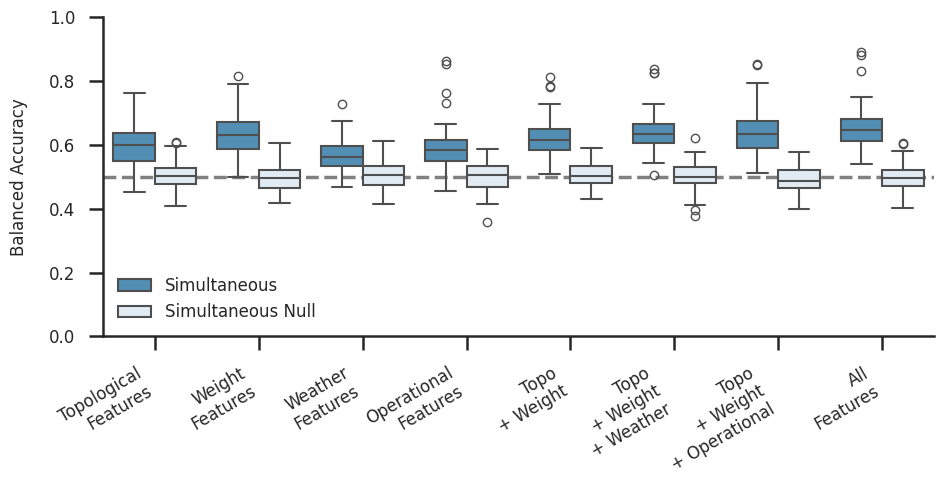

In [44]:
save_dir = results_xgb_plots / "Boxplots_balanced_acc"
os.makedirs(save_dir, exist_ok=True)

stdrcparams(usetex=False)
df1 = pd.DataFrame(balanced_acc)[['Model','Balanced Acc']]
df1['Test'] = 'Simultaneous'
df3 = pd.DataFrame(balanced_acc)[['Model','Balanced Acc Null']].rename(columns={'Balanced Acc Null':'Balanced Acc'})
df3['Test'] = 'Simultaneous Null'
df = pd.concat([df1,df3])

models = [
    'Topological Features',
    'Weight Features',
    'Weather Features',
    'Operational Features',
    # 'Calendar Features',
    
    'Topological + Weight',
    
    # 'Topological + Weight + Calendar',
    'Topological + Weight + Weather',
    'Topological + Weight + Operational',
    'All Features'
]

xlbls = [
    'Topological\nFeatures',
    'Weight\nFeatures',
    'Weather\nFeatures',
    'Operational\nFeatures',
    # 'Calendar\nFeatures',
    'Topo\n+ Weight',
    # 'Topo\n+ Weight\n+ Calendar',
    'Topo\n+ Weight\n+ Weather',
    'Topo\n+ Weight\n+ Operational',
    'All\nFeatures'
]

df = df[df.Model.isin(models)]

fig, ax = plt.subplots(figsize=(xs*1.2, ys))
ax = sns.boxplot(x="Model", y="Balanced Acc", hue='Test',
                 palette=sns.color_palette(['#4292c6','#deebf7']),
                 data=df, ax=ax, linewidth=1.5,
                 order=models,
                 hue_order=['Simultaneous','Simultaneous Null'])
custom_frame(ax)
plt.ylabel('Balanced Accuracy')
plt.xlabel('')
plt.xticks(range(len(xlbls)), xlbls)
plt.xticks(rotation=30, ha='right')
plt.legend(frameon=False)
ax.axhline(y=0.5, linestyle='--', color='grey', linewidth=2.5, zorder=0)
plt.ylim(0, 1)
plt.tight_layout()

# Figure Export Execution
file_path = save_dir / "Base_XGB_BP_Sim.png"
plt.savefig(file_path, bbox_inches='tight', dpi=300)
plt.show()

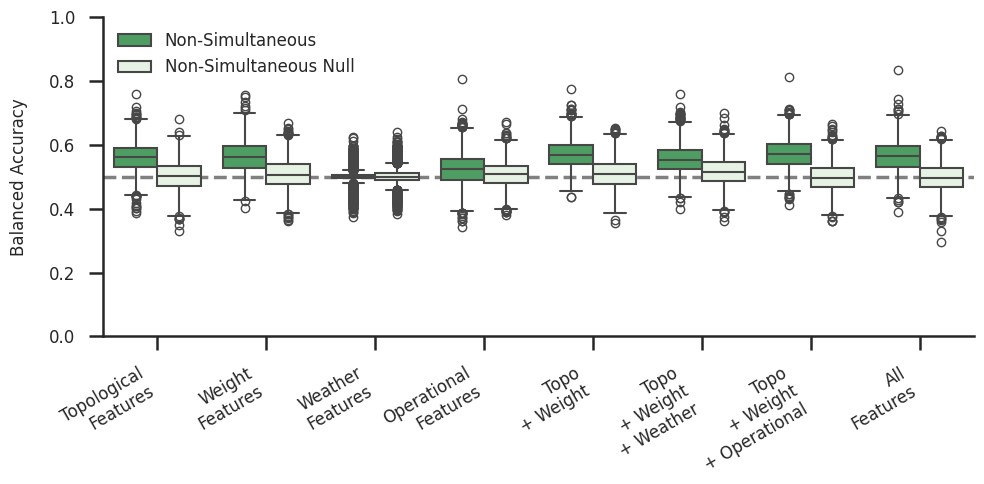

In [45]:
stdrcparams(usetex=False)
df1 = pd.DataFrame(balanced_acc)[['Model','Balanced Acc']]
df1['Test'] = 'Simultaneous'
df2 = pd.DataFrame(balanced_acc_non)[['Model','Balanced Acc']]
df2['Test'] = 'Non-Simultaneous'
df3 = pd.DataFrame(balanced_acc)[['Model','Balanced Acc Null']].rename(columns={'Balanced Acc Null':'Balanced Acc'})
df3['Test'] = 'Simultaneous Null'
df4 = pd.DataFrame(balanced_acc_non)[['Model','Balanced Acc Null']].rename(columns={'Balanced Acc Null':'Balanced Acc'})
df4['Test'] = 'Non-Simultaneous Null'
df = pd.concat([df2,df4])

map_names = {
    'Topological Features': 'TOP',
    'Weight Features': 'WGT',
    'Weather Features': 'WTH',
    'Operational Features': 'OPS',
    # 'Calendar Features': 'CAL',
    'Topological + Weight': 'TW',
    # 'Topological + Weight + Calendar': 'TWC',
    'Topological + Weight + Weather': 'TWCW',
    'Topological + Weight + Operational': 'TWCO',
    'All Features': 'ALLF'
}

# Translate the names in the dataframe
df['Model'] = df['Model'].replace(map_names)

models = [
    'TOP', 
    'WGT', 
    'WTH', 
    'OPS', 
    # 'CAL', 
    'TW', 
    # 'TWC', 
    'TWCW', 
    'TWCO', 
    'ALLF',
]

# xlbls = models.copy()

df = df[df.Model.isin(models)]
fig,ax = plt.subplots(figsize=(xs*1.25,ys))
ax = sns.boxplot(x="Model", y="Balanced Acc",hue='Test',
                 palette=sns.color_palette(['#41ab5d','#e5f5e0']),#,'#41ab5d','#e5f5e0']),
                 data=df,ax=ax,linewidth=1.5,
                 hue_order=['Non-Simultaneous','Non-Simultaneous Null'])#,'Non-Simultaneous','Non-Simultaneous Null'])
custom_frame(ax)
plt.ylabel('Balanced Accuracy')
plt.xlabel('')
plt.xticks(range(len(xlbls)),xlbls)
plt.xticks(rotation=30, ha='right')
plt.legend(frameon=False)
ax.axhline(y=0.5, linestyle = '--',color ='grey', linewidth=2.5, zorder=0)
plt.ylim(0,1)
plt.tight_layout()

file_path = save_dir / "Base_XGB_BP_NonSim.png"
plt.savefig(file_path, bbox_inches='tight', dpi=300)
plt.show()


boxplots timebasedsplits 

In [46]:
# # Combined boxplots for other classifiers: Simultaneous vs Non-Simultaneous
# stdrcparams(usetex=False)
# # `simultaneous_df` and `nonsimultaneous_df` are created above from the results_classifiers folder
# sim_df_plot = simultaneous_df[['Classifier','Balanced Accuracy']].copy()
# sim_df_plot['Test'] = 'Simultaneous'
# nonsim_df_plot = nonsimultaneous_df[['Classifier','Balanced Accuracy']].copy()
# nonsim_df_plot['Test'] = 'Non-Simultaneous'
# plot_df = pd.concat([sim_df_plot, nonsim_df_plot], ignore_index=True)
# # Optionally filter or order classifiers here; by default use the ones present
# classifiers = sorted(plot_df['Classifier'].unique())
# fig, ax = plt.subplots(figsize=(xs*1.5, ys))
# ax = sns.boxplot(x='Classifier', y='Balanced Accuracy', hue='Test',
#                  data=plot_df, ax=ax, linewidth=1.5,
#                  palette=sns.color_palette(['#4292c6','#41ab5d']))
# custom_frame(ax)
# plt.ylabel('Balanced Accuracy')
# plt.xlabel('')
# plt.xticks(rotation=45, ha='right')
# plt.legend(frameon=False)
# ax.axhline(y=0.5, linestyle='--', color='grey', linewidth=2.5)
# plt.ylim(0,1)
# plt.tight_layout()
# plt.show()

### Wilcoxon Signed Rank Test (instead of paired t test), as we do not assume normal distribution

In [60]:
import pandas as pd
import numpy as np
from datetime import datetime, date
from collections import defaultdict
from sklearn.metrics import balanced_accuracy_score

# --- 1. Extract Simultaneous Performance ---
year_list = df_simultaneousClassification_TOP.YearMonth.unique()
balanced_acc = defaultdict(list)

for name, df in df_simultaneousClassification.items():
    for year in year_list:
        period_year = pd.Period(year, freq='M')
        
        # Filter for the specific year/month
        df_filtered = df[df.YearMonth == year]
        if df_filtered.empty:
            continue
            
        y_test, y_predict, y_null = df_filtered[['target_binary', 'simultaneous_pred', 'simultaneous_null']].values.T
        
        balanced_acc['Model'].append(name)
        balanced_acc['YearMonth'].append(period_year) # <-- Critical addition
        balanced_acc['Balanced Acc'].append(balanced_accuracy_score(y_test, y_predict))
        balanced_acc['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))

df_sim = pd.DataFrame(balanced_acc)


# --- 2. Extract Non-Simultaneous Performance ---
file_path = results_xgb / "balanced_acc_non_wilcoxon.pkl"

if file_path.exists():
    df_non = pd.read_pickle(file_path)
    print("read from path")
else:
    balanced_acc_non = defaultdict(list)
    
    for name, data_list in df_nonsimultaneousClassification.items():
        for year_train, year_test, y_test, y_pred, y_null in data_list:
            period_year_train = pd.Period(year_train, freq='M')
            period_year_test = pd.Period(year_test, freq='M')

            if period_year_train != period_year_test and period_year_train < pd.Period('2024-01', freq='M'):
                balanced_acc_non['Model'].append(name)
                balanced_acc_non['YearMonth'].append(period_year_test) # <-- Match on TEST period
                balanced_acc_non['Balanced Acc'].append(balanced_accuracy_score(y_test, y_pred))
                balanced_acc_non['Balanced Acc Null'].append(balanced_accuracy_score(y_test, y_null))

    df_non = pd.DataFrame(balanced_acc_non)
    
    # If a test month was predicted by multiple training months, we need to average them 
    # so we have exactly one non-simultaneous score per test month per model.
    df_non = df_non.groupby(['Model', 'YearMonth']).mean(numeric_only=True).reset_index()
    
    df_non.to_pickle(file_path)

# --- 3. Merge into a Paired Dataset ---
# We merge on Model and YearMonth to ensure perfect pairing
df_paired = pd.merge(
    df_sim, 
    df_non, 
    on=['Model', 'YearMonth'], 
    suffixes=('_sim', '_non')
)

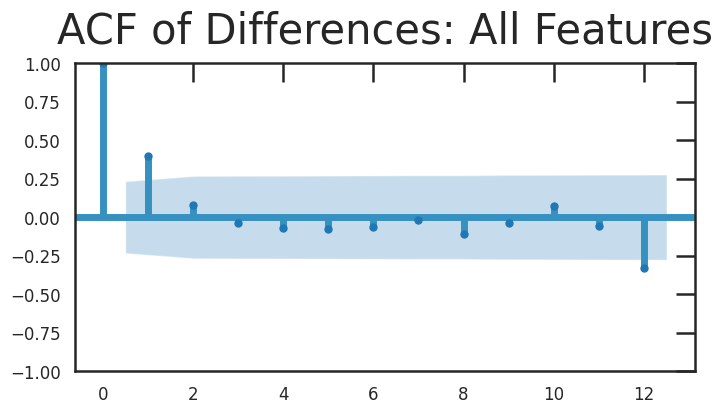

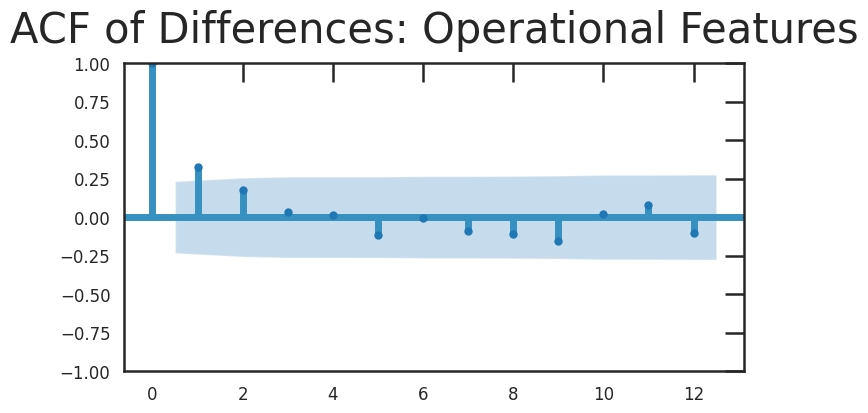

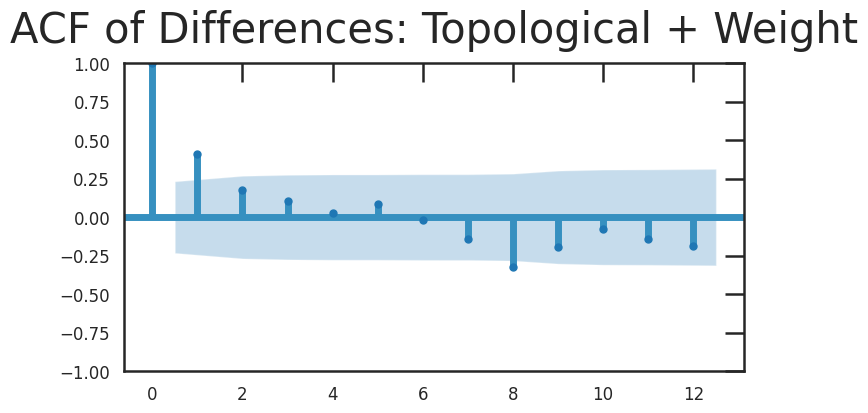

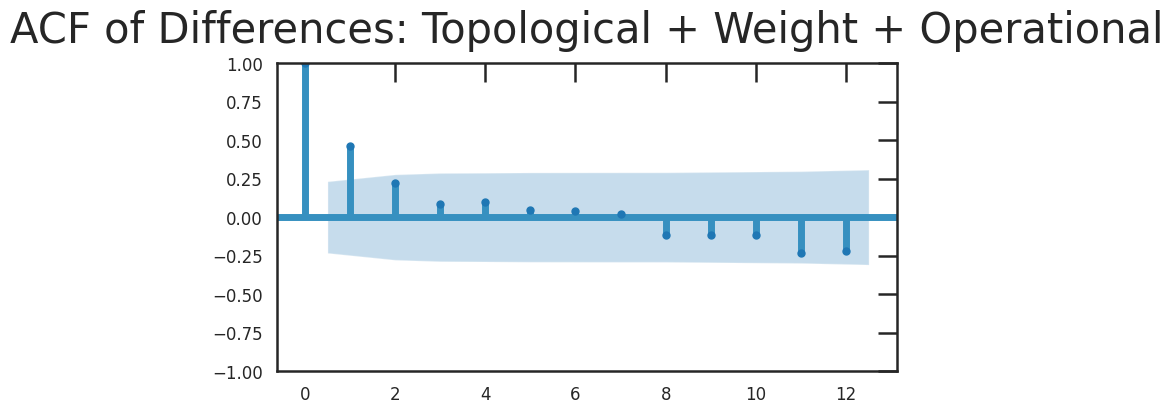

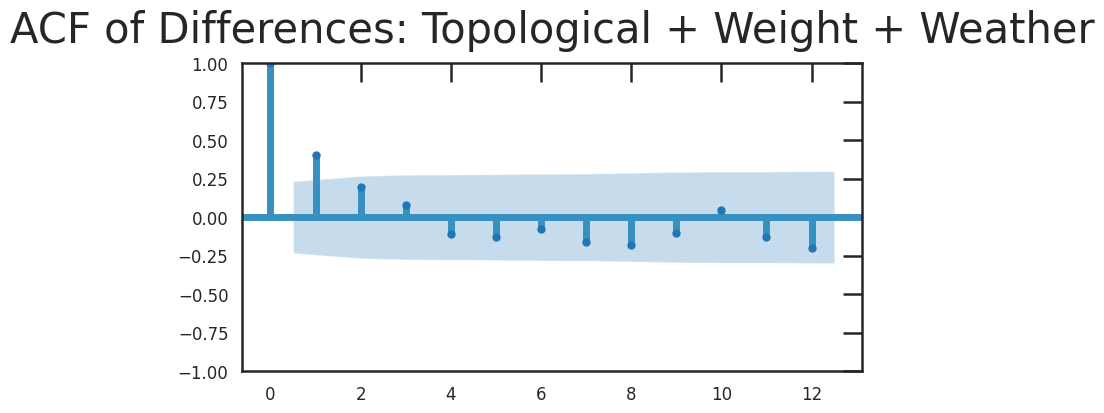

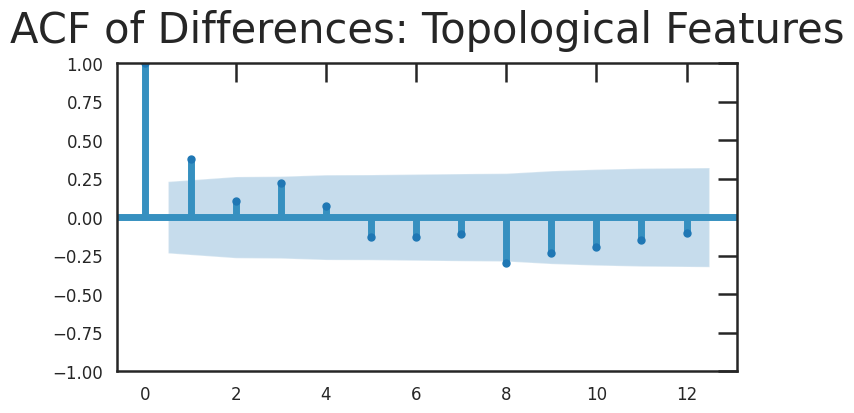

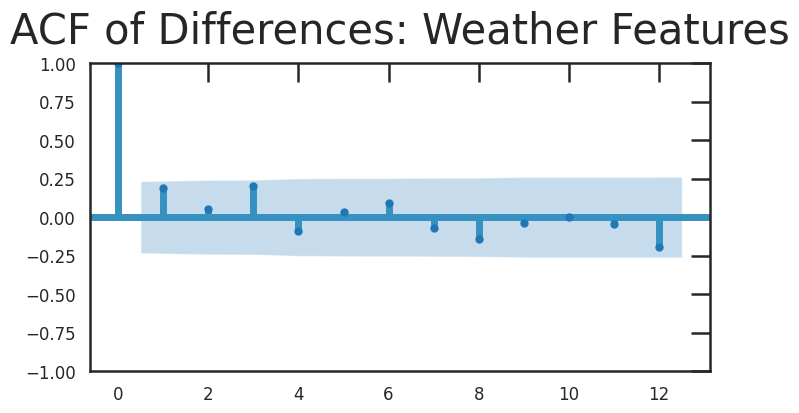

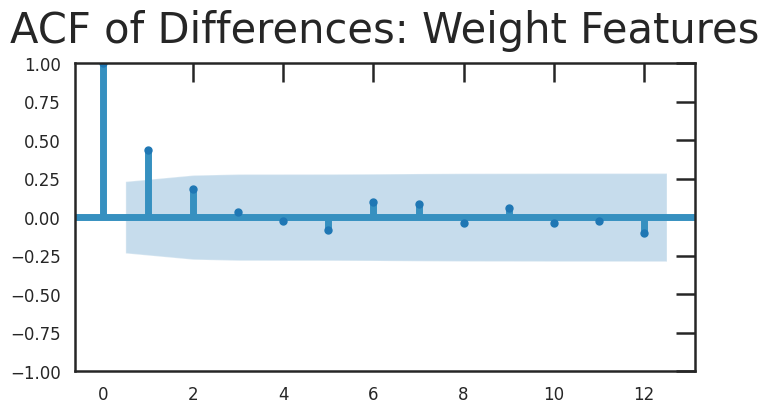


--- Wilcoxon Test Results ---
                             Model  Mean Acc (Simultaneous)  Mean Acc (Non-Simultaneous)  Wilcoxon Statistic      p-value  Significant (alpha=0.05)
                      All Features                 0.651737                     0.562343                25.0 6.997485e-13                      True
              Operational Features                 0.589294                     0.527281               138.0 6.489158e-11                      True
              Topological + Weight                 0.622615                     0.571215               243.0 3.022342e-09                      True
Topological + Weight + Operational                 0.635651                     0.570795               163.0 1.672287e-10                      True
    Topological + Weight + Weather                 0.639265                     0.555216                15.0 4.594535e-13                      True
              Topological Features                 0.598160                     0

In [63]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.graphics.tsaplots import plot_acf

# Dictionary to store the results of the Wilcoxon test
wilcoxon_results = []

# Loop through each model in the merged dataset
for model_name, group in df_paired.groupby('Model'):
    
    # Sort chronologically to ensure time-series integrity for ACF
    group = group.sort_values('YearMonth')
    
    # Calculate the sequence of differences
    differences = group['Balanced Acc_sim'] - group['Balanced Acc_non']
    
    # --- Check Autocorrelation ---
    # Plot ACF (using half the length of the dataset for lags as a rule of thumb)
    max_lags = min(12, len(differences) // 2)
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_acf(differences, lags=max_lags, ax=ax, title=f"ACF of Differences: {model_name}")
    plt.show()
    
    # --- Perform Wilcoxon Signed-Rank Test ---
    # The Wilcoxon test expects two paired arrays of the same length
    stat, p_value = wilcoxon(group['Balanced Acc_sim'], group['Balanced Acc_non'])
    
    # Calculate average accuracies for context
    mean_sim = group['Balanced Acc_sim'].mean()
    mean_non = group['Balanced Acc_non'].mean()
    
    wilcoxon_results.append({
        'Model': model_name,
        'Mean Acc (Simultaneous)': mean_sim,
        'Mean Acc (Non-Simultaneous)': mean_non,
        'Wilcoxon Statistic': stat,
        'p-value': p_value,
        'Significant (alpha=0.05)': p_value < 0.05
    })

# Output the final test results
df_results = pd.DataFrame(wilcoxon_results)
print("\n--- Wilcoxon Test Results ---")
print(df_results.to_string(index=False))

## SHAP-values

SHAP loading complete.
Loaded models: ['TOP', 'WGT', 'WTH', 'OPS', 'TW', 'TWCW', 'TWCO', 'ALLF']
TOP


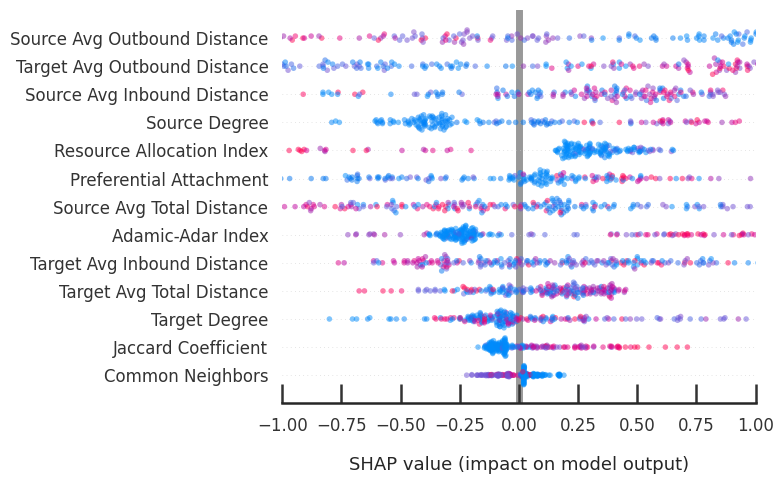

WGT


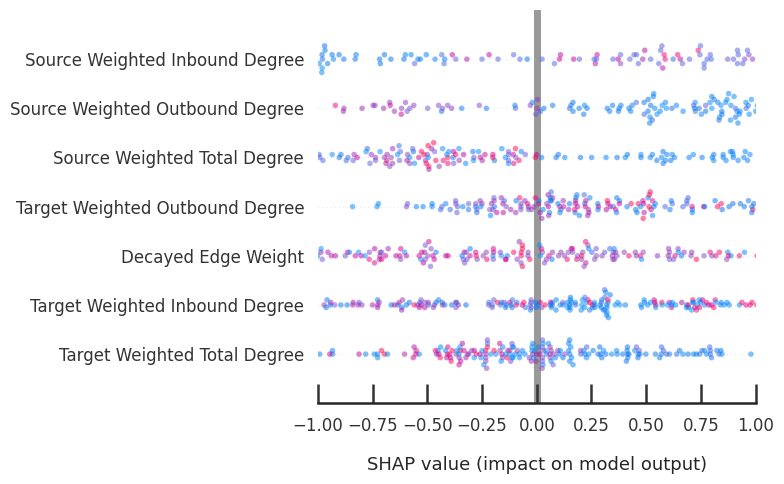

WTH


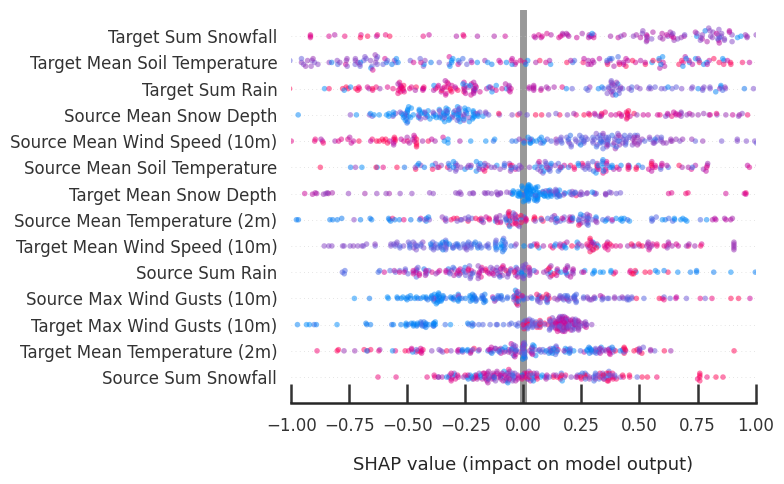

OPS


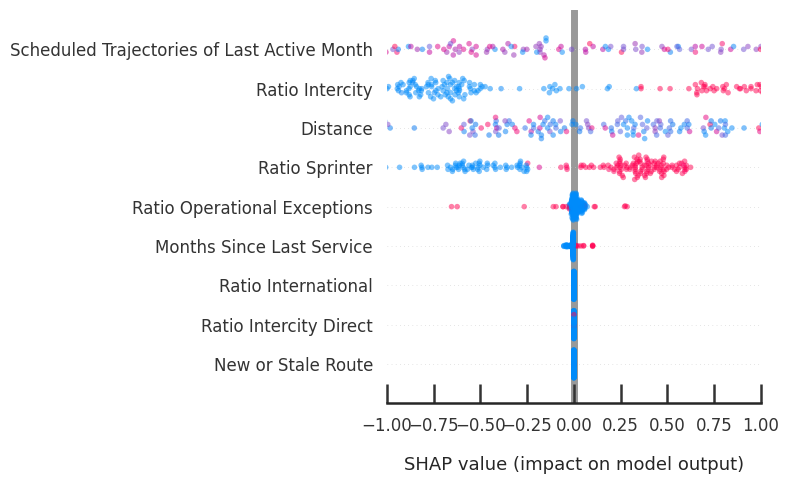

TW


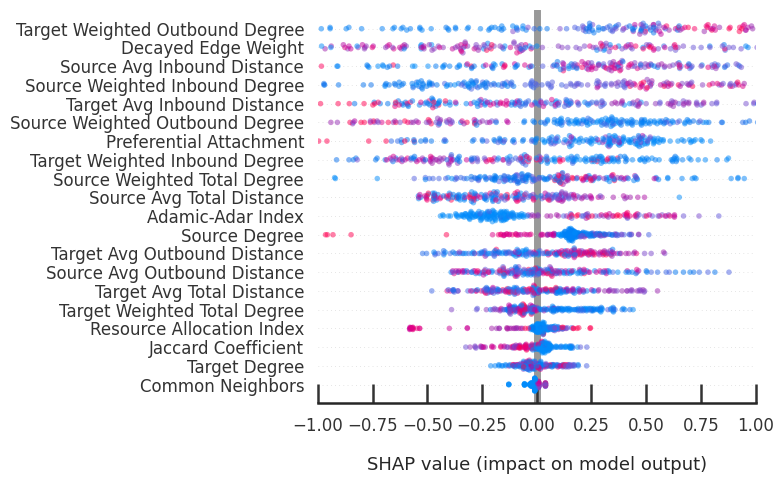

TWCW


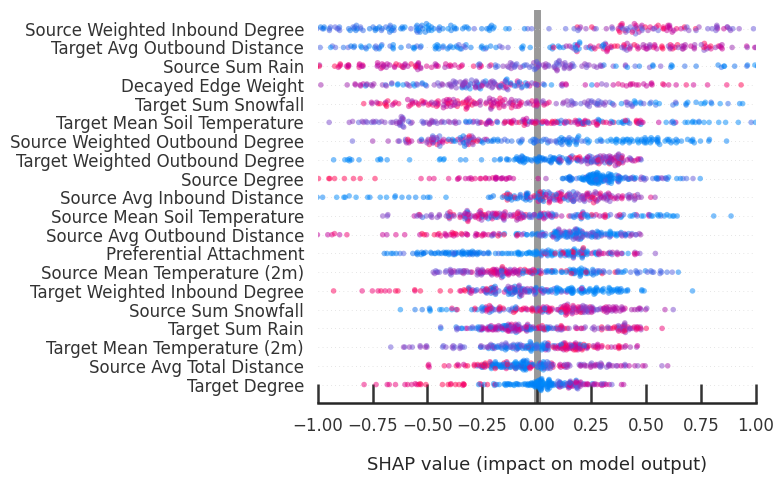

TWCO


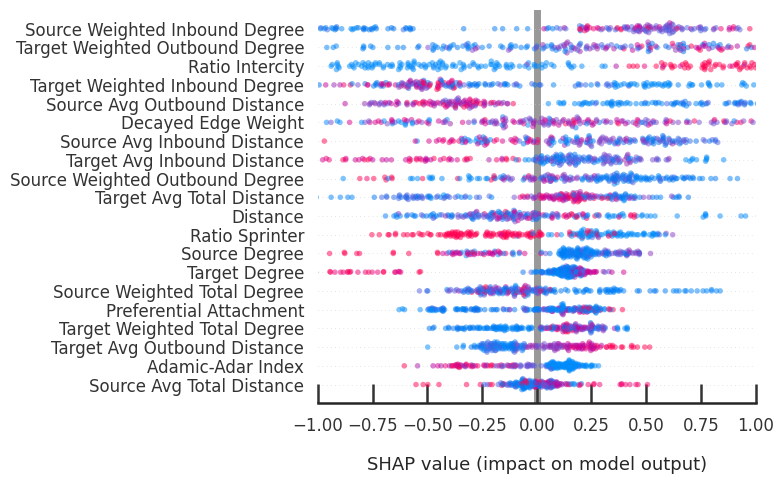

ALLF


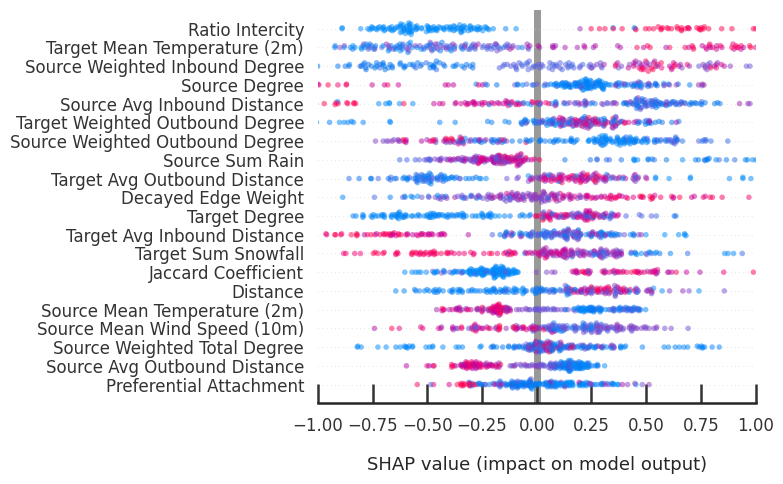

In [47]:
import shap
import pickle


def singleShap(test_list, year_list, shap_list, suffix):
    year = pd.to_datetime('2024-01-01')
    idx = year_list.index(year)
    shap_values = shap_list[idx]
    test_df = test_list[idx]
    
    # Map feature names
    test_df.columns = [feature_name_map.get(col, col) for col in test_df.columns]

    fig, ax = plt.subplots(figsize=(8, 5))
    shap.summary_plot(shap_values, test_df, alpha=0.5, show=False,
                      color_bar=False, plot_size=(8, 5))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Extract and map y-axis labels
    labels = [item.get_text() for item in ax.get_yticklabels()]
    mapped_labels = [feature_name_map.get(label, label) for label in labels]
    ax.set_yticklabels(mapped_labels)
    ax.set_xlim(-1, 1)
    
    plt.tight_layout()
    
    # Figure Export Execution
    file_path = results_xgb_plots / f"Base_XGB_Shap_{suffix}.png"
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

# 1. Map models to their exact file prefixes
file_mapping = {
    'TOP': 'NS_I_TOP',
    'WGT': 'NS_I_WGT',
    'WTH': 'NS_I_WTH',
    'OPS': 'NS_I_OPS',
    # 'CAL': 'NS_I_CAL',
    'TW': 'NS_C_TW',
    # 'TWC': 'NS_C_TWC',
    'TWCW': 'NS_C_TWCW',
    'TWCO': 'NS_C_TWCO',
    'ALLF': 'NS_C_ALLF'
}

df_SHAPClassification = {}

# 2. Loop through and load each file dynamically
for model, prefix in file_mapping.items():
    file_path = f"{results_xgb}/{prefix}_SHAP.pkl" 
    
    try:
        with open(file_path, 'rb') as f:
            df_SHAPClassification[model] = pickle.load(f)
    except FileNotFoundError:
        print(f"Warning: Could not find {file_path}")

print("SHAP loading complete.")
print(f"Loaded models: {list(df_SHAPClassification.keys())}")

for name, df in df_SHAPClassification.items():
    print(name)
    # The dictionary key is passed as the required suffix parameter
    singleShap(*df, suffix=name)

## Year On Year SHAP feature importance

In [50]:
def get_temporal_order(shap_list):
    importance_array = []
    for shap_values in shap_list: 
        array = -np.abs(shap_values).mean(0)
        order = array.argsort()
        ranks = order.argsort()
        importance_array.append(ranks+1)
    return(np.array(importance_array))

TOP


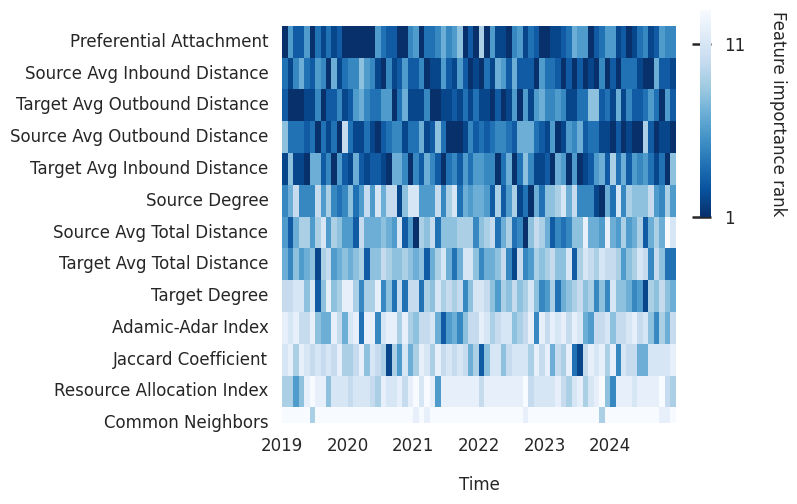

WGT


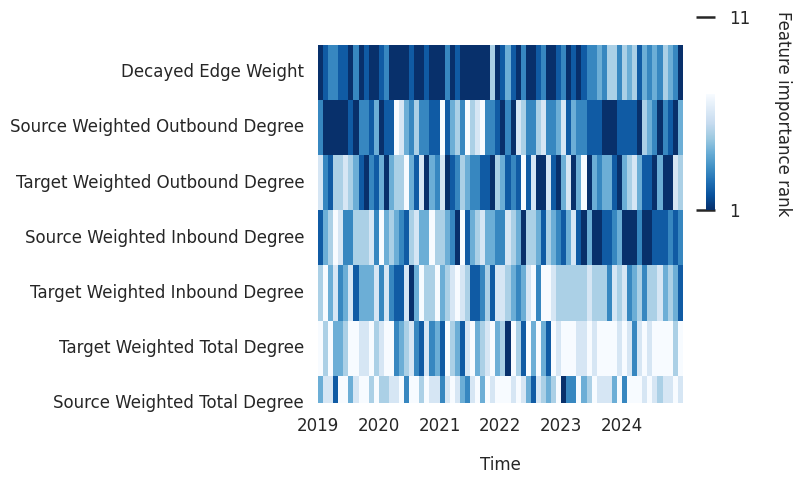

WTH


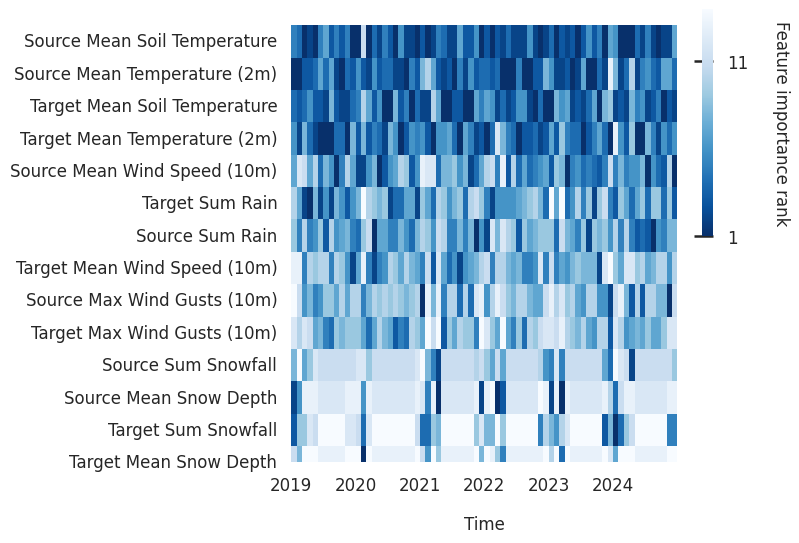

OPS


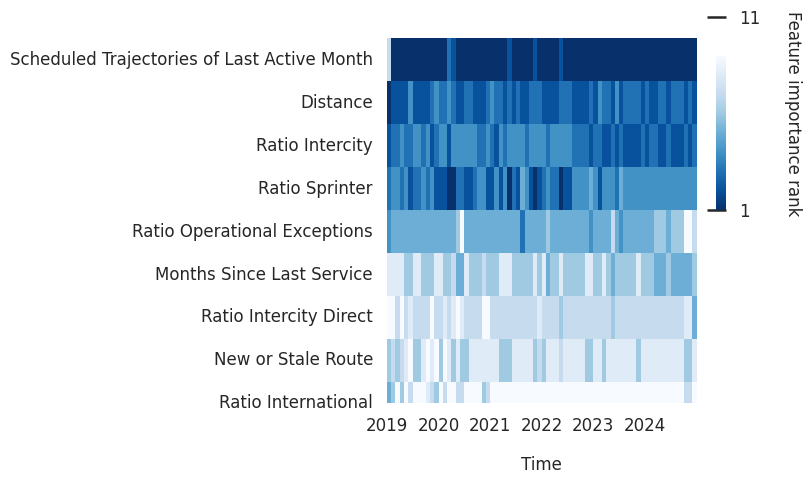

TW


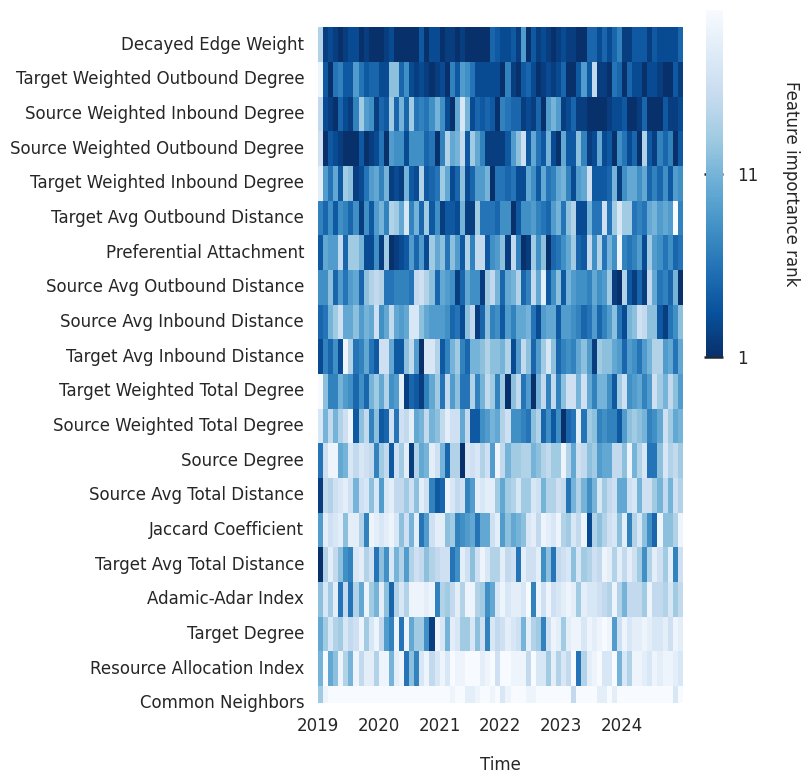

TWCW


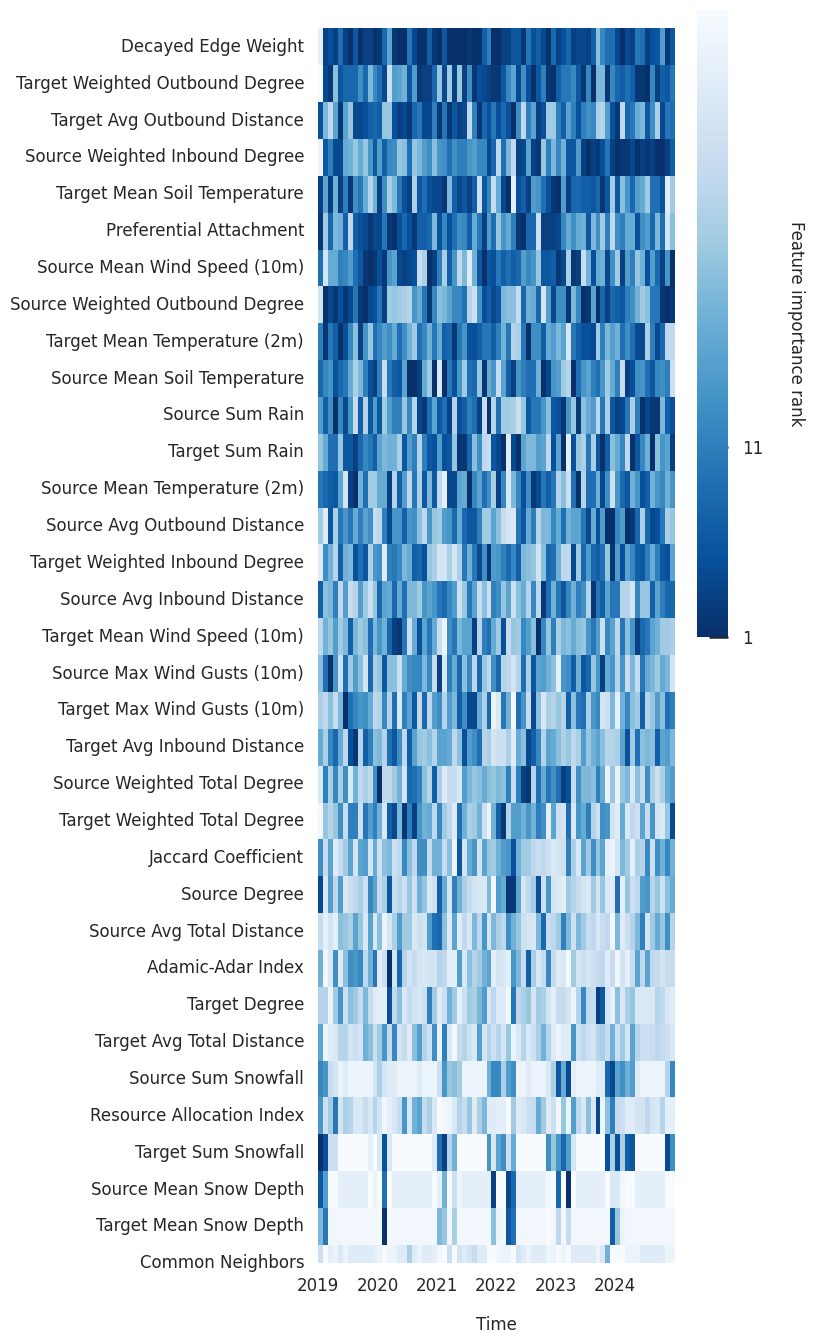

TWCO


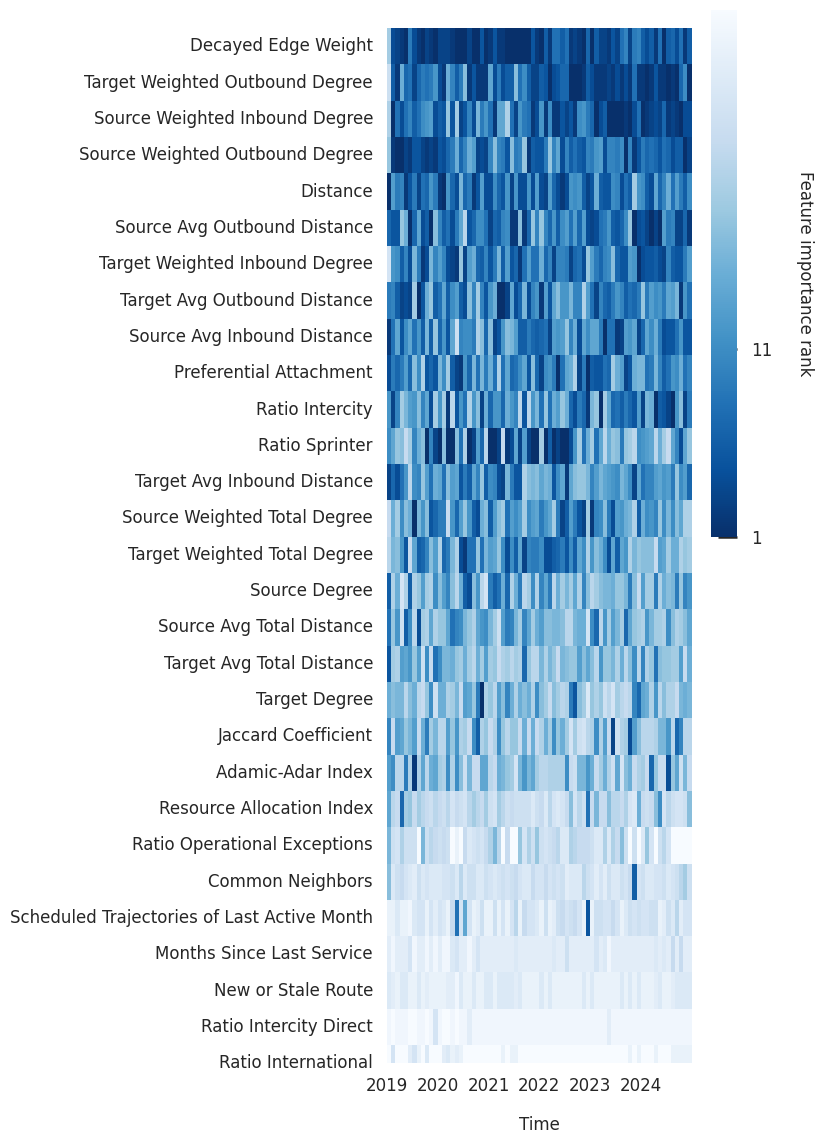

ALLF


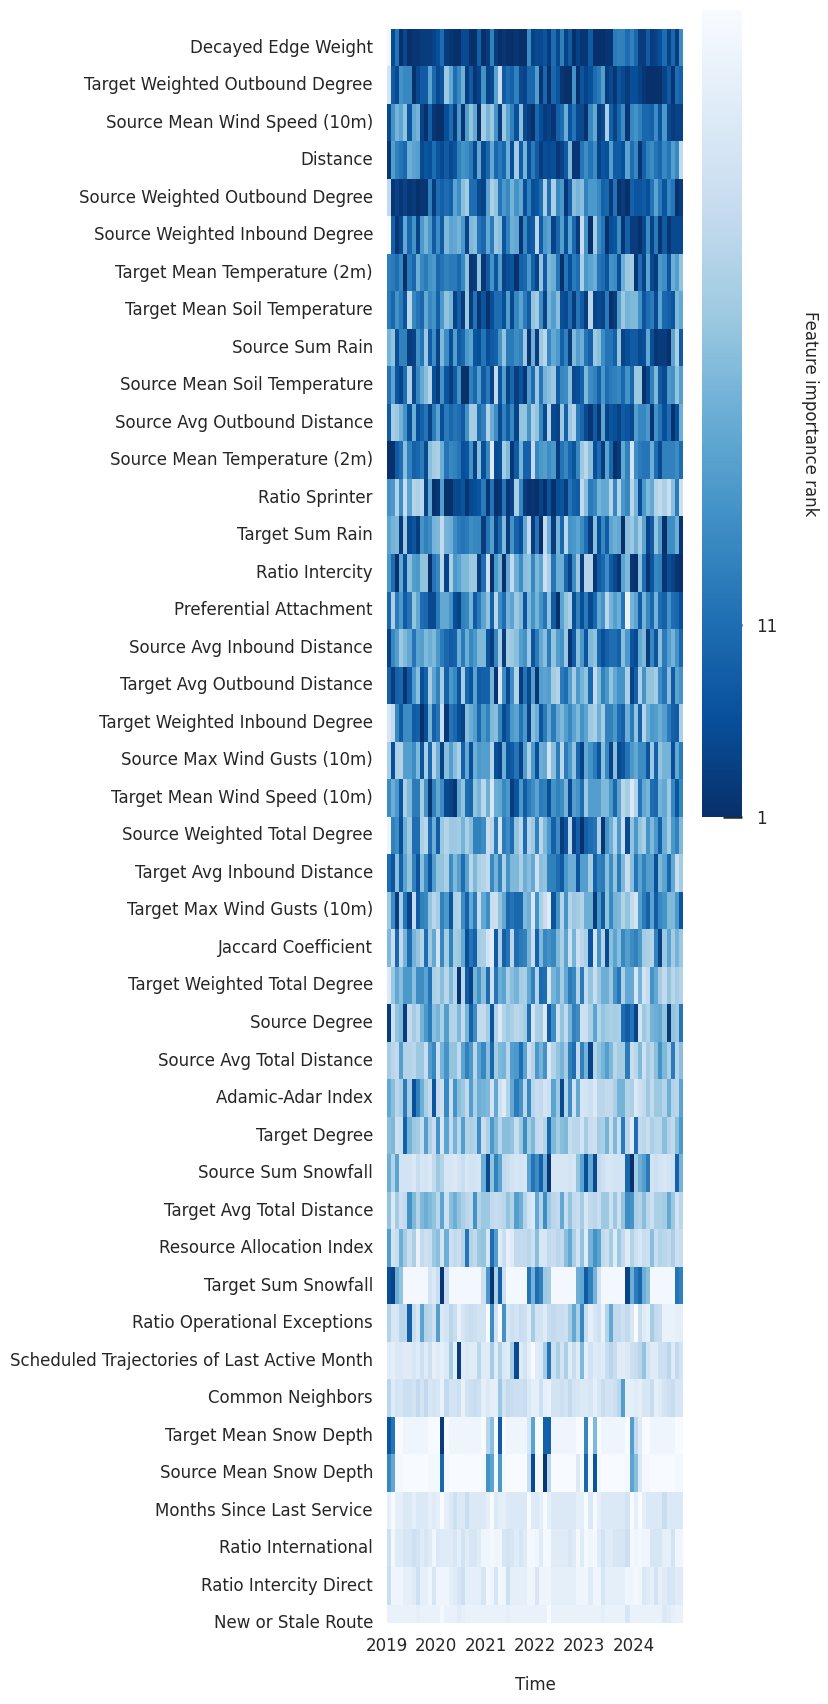

In [51]:
for name, df in df_SHAPClassification.items():
	print(name)
	features = list(df[0][0].columns)
	num_features = len(features)
	dynamic_ys = max(ys, num_features * 0.4)

	fig, ax = plt.subplots(figsize=(xs, dynamic_ys))
	
	importance = get_temporal_order(df[2][0:0+24*8])
	
	mean_ranks = importance.T.mean(axis=1)
	sort_indices = np.argsort(mean_ranks)

	x = importance.T[sort_indices]
	y = [features[i] for i in sort_indices]
	
	# Sort the features in the correct order and ensure consistent y-ticks
	sorted_features = [feature_name_map.get(f, f) for f in y]
	
	ax = sns.heatmap(x,
					cmap='Blues_r',
					yticklabels=sorted_features,
					xticklabels=False,
					cbar_kws={'label': 'Feature importance rank',
							'ticks': [2, 4, 6, 8, 10] ,
							'shrink': 0.5,
							'anchor': (0.0, 1.0)})
	cbar = ax.collections[0].colorbar
	cbar.set_ticks([1, 11])
	cbar.set_label('Feature importance rank', labelpad=30, rotation=360-90)
	plt.ylim(num_features - 0.5, -0.5)  # Adjust y-axis limits based on the number of features

	# Set the xticks for the years from 2019 to 2024
	num_months = (2024 - 2019) * 12  
	plt.xticks([12 * i for i in range(num_months // 12 + 1)], 
			[2019 + i for i in range(num_months // 12 + 1)])

	plt.xlabel('Time')
	ax.tick_params(top=False)  # Remove the lines at the top
	ax.tick_params(right=False)  # Remove the lines at the top


	# Rotate the y-tick labels to horizontal if the features are unweighted topological features
	if "Unweighted" in name:
		ax.yaxis.set_tick_params(rotation=0)

	plt.tight_layout()
	plt.show()

## SHAP feature importance (monthly aggregated)

TOP


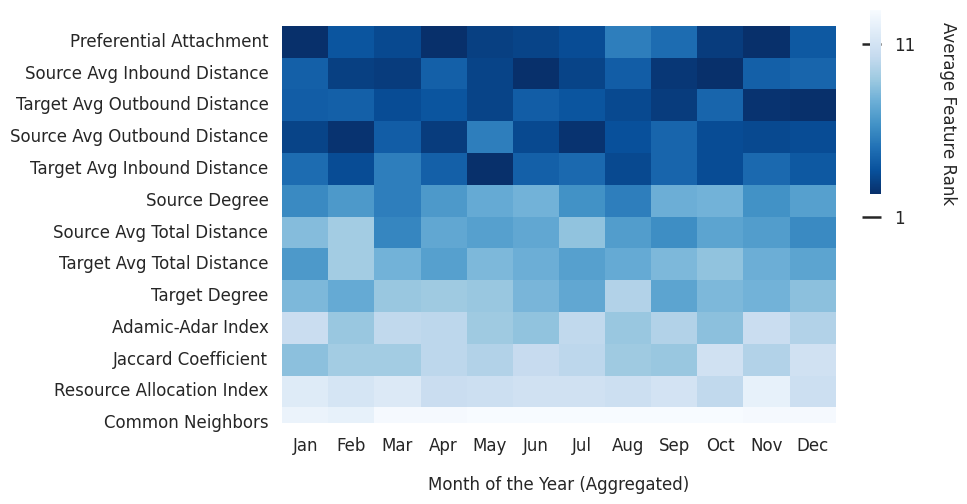

WGT


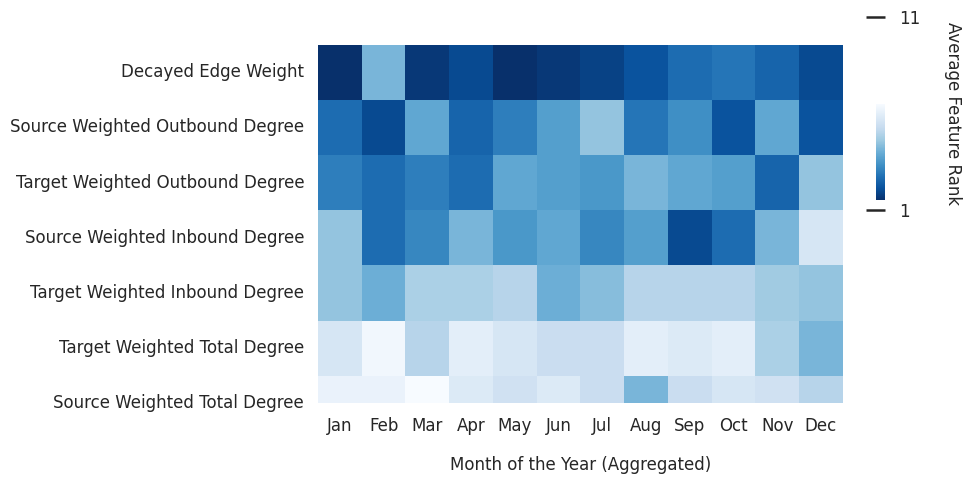

WTH


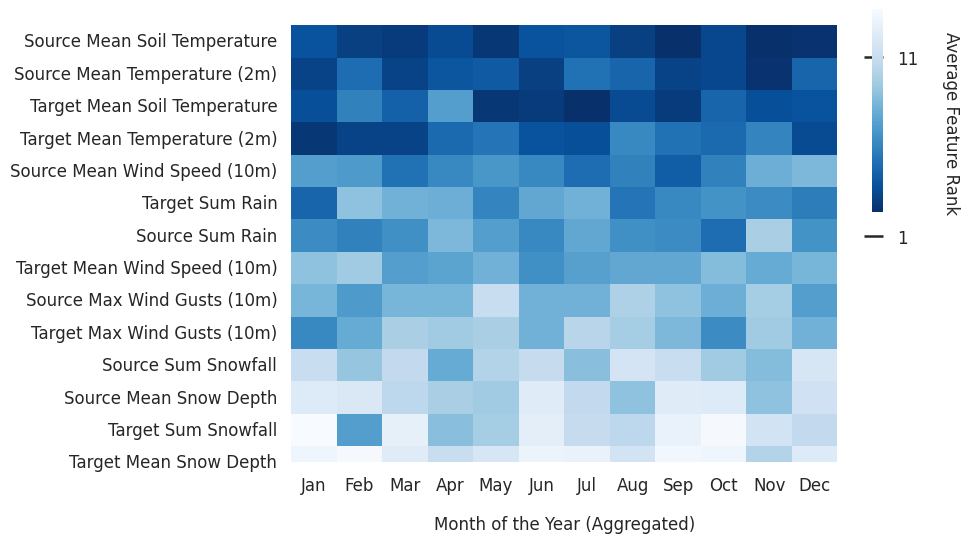

OPS


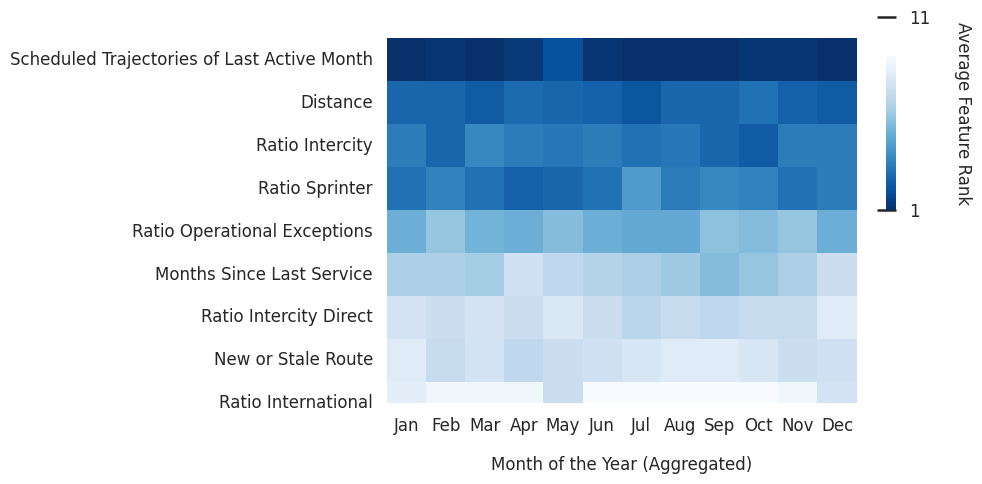

TW


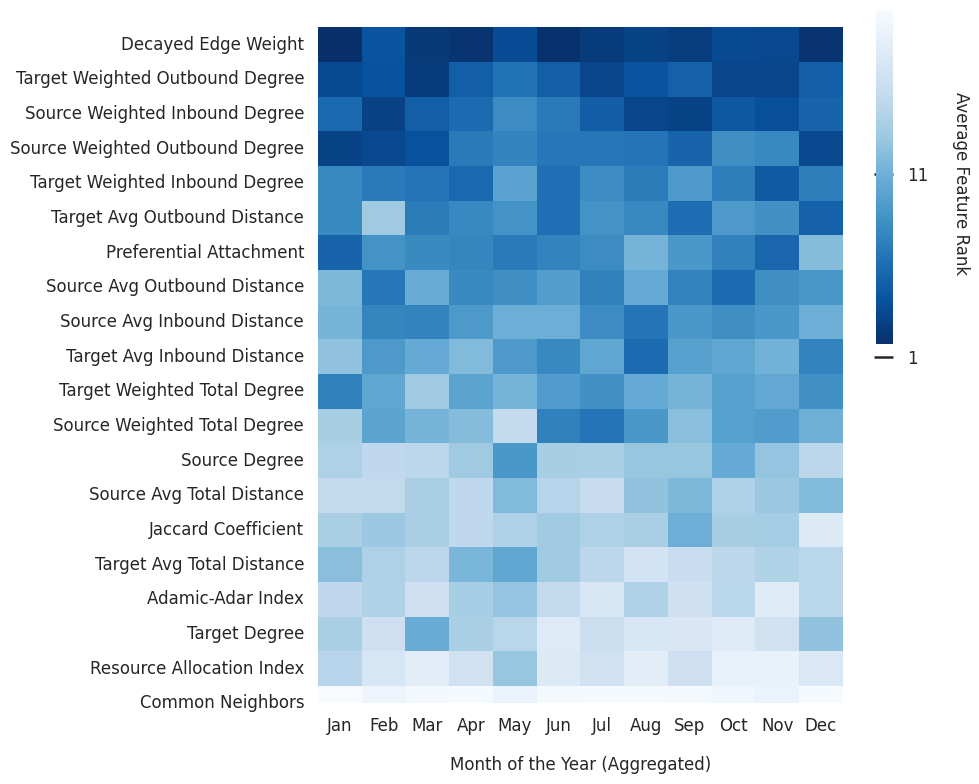

TWCW


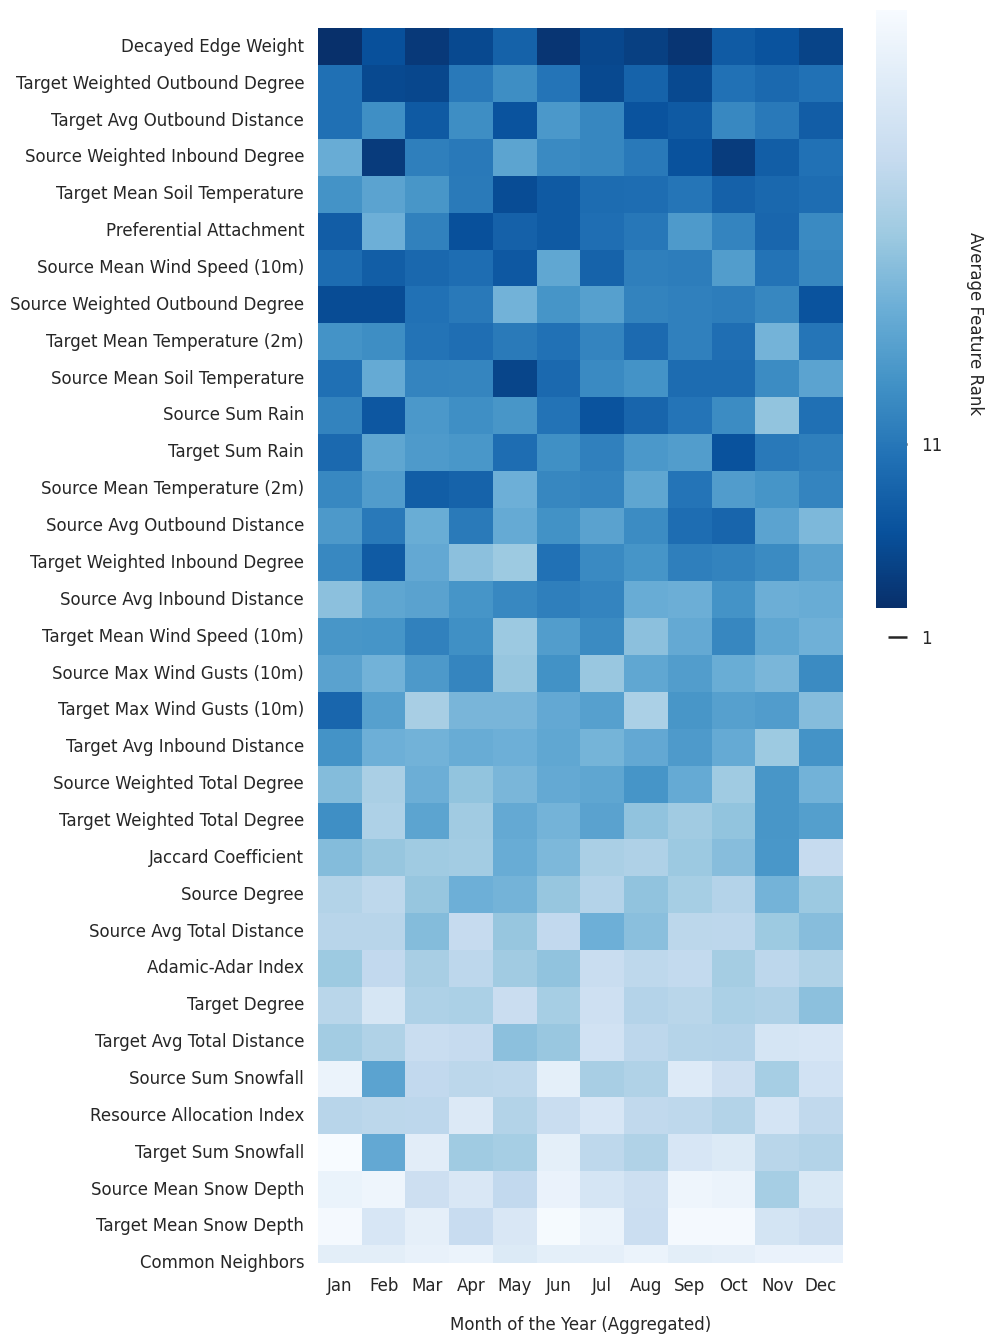

TWCO


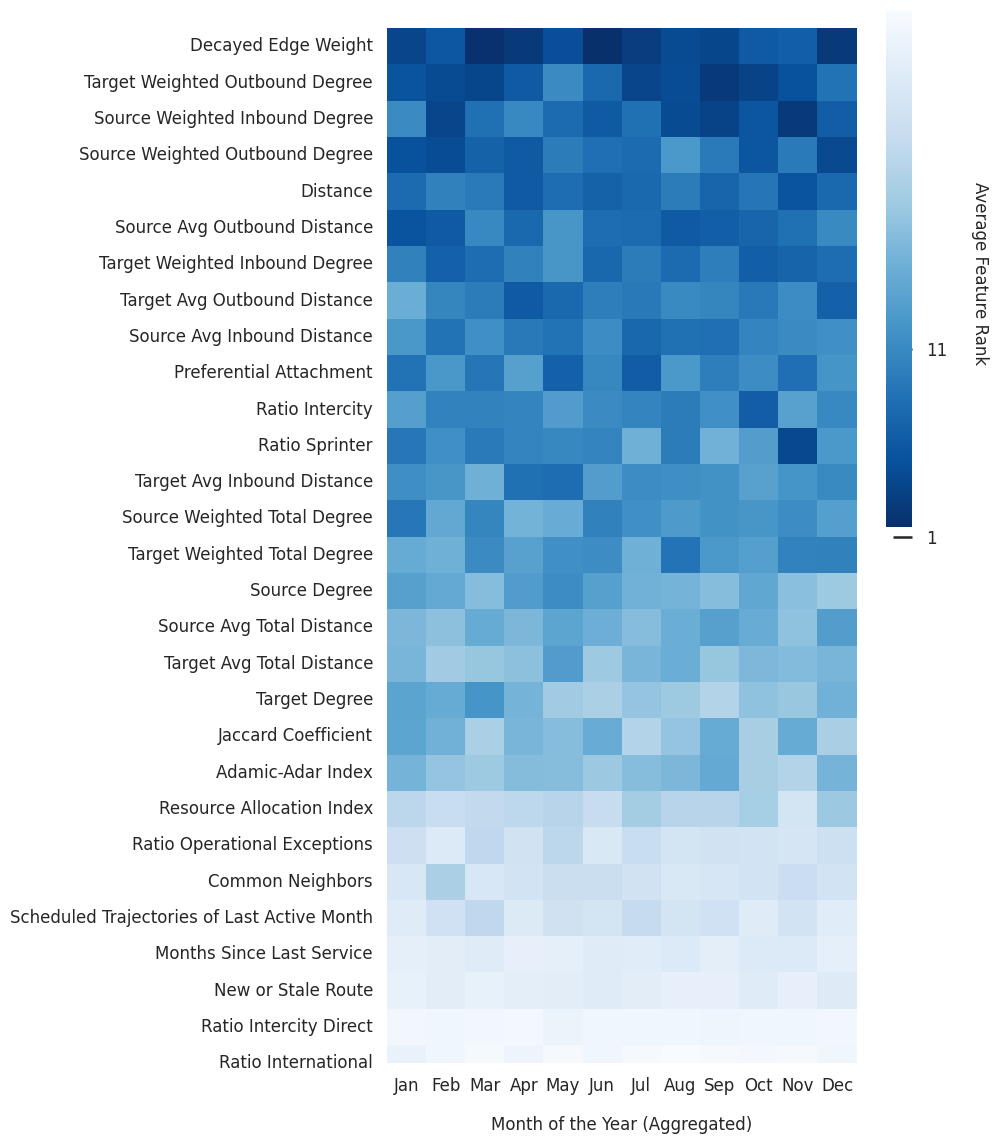

ALLF


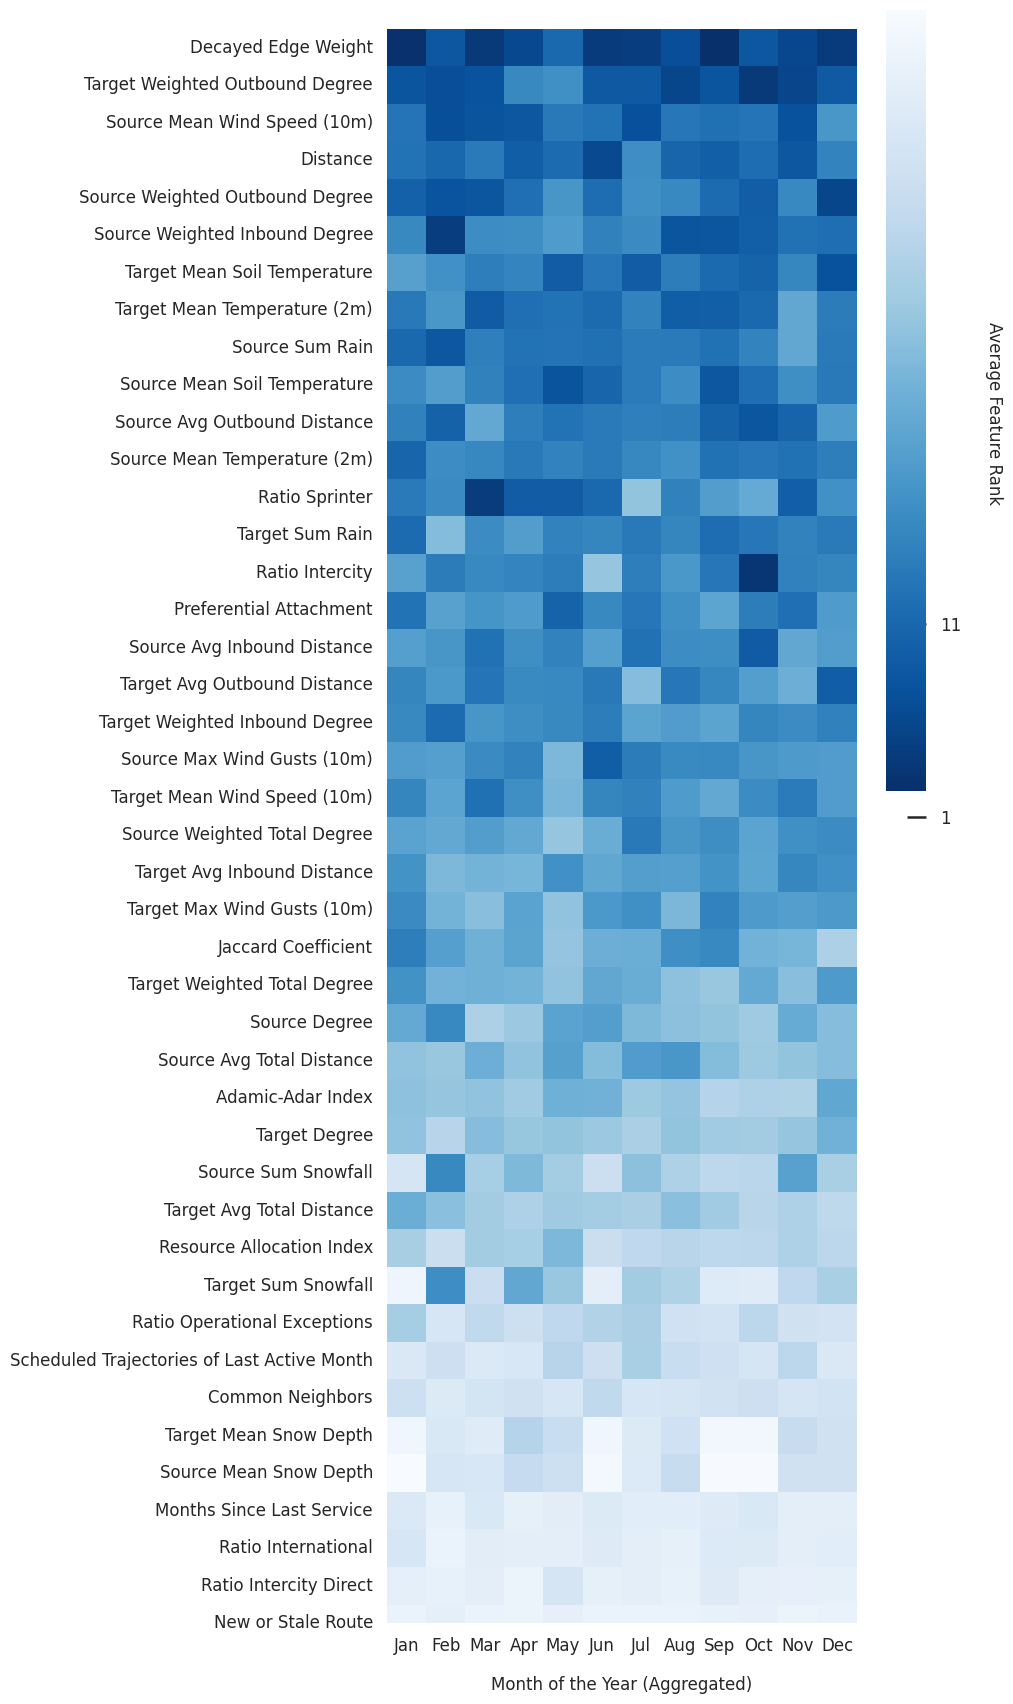

In [52]:
import pandas as pd
import numpy as np
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

for name, df in df_SHAPClassification.items():
	print(name)
	features = list(df[0][0].columns)
	num_features = len(features)
	
	# 1. Dynamic Height
	dynamic_ys = max(ys, num_features * 0.4) 
	fig, ax = plt.subplots(figsize=(10, dynamic_ys)) 
	
	# 2. Get the raw temporal ranks (shape: time_steps x features)
	importance = get_temporal_order(df[2][0:len(year_list)]) 
	
	# Aggregation by month
	# Extract just the month integer (1-12)
	month_labels = [ts.month for ts in year_list[:len(importance)]]
	
	# Put the ranks into a DataFrame, group by the month, and average them
	importance_df = pd.DataFrame(importance, index=month_labels)
	seasonal_importance = importance_df.groupby(level=0).mean()
	
	# 3. Sort features based on their overall average rank across the 12 months
	mean_ranks = seasonal_importance.mean(axis=0)
	sort_indices = np.argsort(mean_ranks)

	# Transpose so features are on the Y-axis and months are on the X-axis
	x = seasonal_importance.values.T[sort_indices]
	y = [features[i] for i in sort_indices]
	
	# Map the descriptive names
	sorted_features = [feature_name_map.get(f, f) for f in y]
	
	# 4. Plot the Heatmap
	# Generate clean month names (Jan, Feb, Mar...) for the X-axis
	month_names = [calendar.month_abbr[i] for i in seasonal_importance.index]
	
	ax = sns.heatmap(x,
					cmap='Blues_r',
					yticklabels=sorted_features,
					xticklabels=month_names, # Use the clean month names!
					cbar_kws={'label': 'Average Feature Rank',
							'ticks': [2, 4, 6, 8, 10],
							'shrink': 0.5,
							'anchor': (0.0, 1.0)})
	
	cbar = ax.collections[0].colorbar
	cbar.set_ticks([1, 11])
	cbar.set_label('Average Feature Rank', labelpad=30, rotation=270)
	plt.ylim(num_features - 0.5, -0.5) 

	plt.xlabel('Month of the Year (Aggregated)')
	ax.tick_params(top=False, right=False) 

	if "Unweighted" in name:
		ax.yaxis.set_tick_params(rotation=0)

	plt.tight_layout() 
	plt.show()